# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

## Intro

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18

In [2]:
from halo_and_cluster_MF import *
from useful_functions import *

In [3]:
# Set the style for the plots
plt.rcParams.update({
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20
})

In [4]:
cosmo = Planck18

In [5]:
colors = ["blue", "cyan", "green", "darkorange", "saddlebrown","red"]
cmap_blue2red = LinearSegmentedColormap.from_list("blue2red", colors)

In [ ]:
# Fonctions pour raccourcir le code
def compute_histogram_density(data, bins=100, range=None, volume=1.0): #Attention : on ne ressort ici 
    """
    Compute histogram, bin centers, bin width, and density for a given data array.

    Args:
        data (array-like): Input data (e.g., log-mass, richness, luminosity).
        bins (int): Number of bins.
        range (tuple): Range for the histogram.
        volume (float or array-like): Survey volume for normalization.

    Returns:
        bin_centers (np.ndarray): Centers of the bins.
        counts (np.ndarray): Counts per bin.
        bin_width (float): Width of each bin.
        density (np.ndarray): Density per bin (counts/bin_width/volume).
    """
    counts, bin_edges = np.histogram(data, bins=bins, range=range)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = np.diff(bin_edges)[0]  # Assuming uniform bin width
    density = (counts/bin_width)/volume
    return bin_centers, counts, bin_width, density

def compute_poisson_errors(counts, bin_width, normalize=False):
    """
    Compute Poisson errors for histogram bins, optionally normalized.

    Args:
        counts (np.ndarray): Counts per bin.
        bin_width (float): Bin width.
        normalize (bool): If true, normalize errors by (total * bin_width)

    Returns:
        errors (np.ndarray): Poisson errors (normalized if total is given).
    """
    errors = np.sqrt(counts)
    if normalize:
        total = np.sum(counts)
        errors = errors / (total * bin_width)
    return errors

def process_subtables_histogram(subtables, column, bins, range, volume, label_prefix, color_map):
    """
    Compute and plot histograms/densities for a list of subtables (e.g., redshift bins).

    Args:
        subtables (list of DataFrame): List of subtables.
        column (str): Column name to process.
        bins (int): Number of bins.
        range (tuple): Histogram range.
        volume (float): Survey volume.
        label_prefix (str): Prefix for legend labels.
        color_map (callable): Function mapping index to color.
    """
    results = []
    for i, subtable in enumerate(subtables):
        data = subtable[column]
        bin_centers, counts, bin_width, density = compute_histogram_density(
            data, bins=bins, range=range, volume=volume
        )
        norm_counts = counts / (np.sum(counts) * bin_width)
        errors = compute_poisson_errors(counts, bin_width)
        norm_errors = compute_poisson_errors(counts, bin_width, normalize=True)
        
        results.append({
            'bin_centers': bin_centers,
            'counts': counts,
            'norm_counts': norm_counts,
            'density': density,
            'errors': errors,
            'norm_errors': norm_errors,
            'color': color_map(i / (len(subtables) - 1))
        })
    return results

def add_apparent_luminosity(df, Labs_col, z_col, cosmo, new_col='Lapp'):
    """
    Add a column for apparent luminosity to a DataFrame.

    Args:
        df (pd.DataFrame): Input DataFrame.
        Labs_col (str): Name of the absolute luminosity column.
        z_col (str): Name of the redshift column.
        cosmo (astropy.cosmology): Cosmology object for distance calculation.
        new_col (str): Name for the new column.

    Returns:
        pd.DataFrame: DataFrame with new column added.
    """
    df = df.copy()
    Lapp = []
    for _, row in df.iterrows():
        Labs = row[Labs_col]
        z = row[z_col]
        DL = (cosmo.luminosity_distance(z).value)*1e6  # Distance lumineuse en pc
        Lapp.append(((10/DL)**2) * Labs)  # Conversion de L1Mpc à Lapp
    df[new_col] = Lapp
    return df

# Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

Les valeurs suivantes et définitions de fonction de masse des amas (CMF) sont tirées de Friver et al. 2022.

## Implémentation

In [7]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
bounds_params_GSR = [(14.13-0.40,14.13+0.43),(-3.96-0.82,-3.96+0.55),(-1.68-0.24,-1.68+0.21),(0.63-0.11,0.63+0.25)]

# Params SR (SDSS5 + REFLEX II)
params_SR = [14.44,-4.52,-1.85,0.79] # valeurs moyennes 
bounds_params_SR = [(14.44-0.38,14.44+0.25),(-4.52-0.58,-4.52+0.66),(-1.85-0.18,-1.85+0.21),(0.79-0.18,0.79+0.23)]

# Params GR (GAMA5 + REFLEX II)
params_GR = [13.72,-3.44,-1.29,0.55] # valeurs moyennes
bounds_params_GR = [(13.72-0.43,13.72+0.64),(-3.44-0.93,-3.44+0.26),(-1.29-0.41,-1.29+0.32),(0.55-0.08,0.55+0.26)]

# Params GS (GAMA5 + SDSS5)
params_GS = [14.35,-4.38,-1.96,0.60] # valeurs moyennes
bounds_params_GS = [(14.35-0.60,14.35+0.36),(-4.38-0.73,-4.38+0.93),(-1.96-0.18,-1.96+0.37),(0.60-0.10,0.60+0.15)]

In [8]:
# On paramètres les CMF (Cluster Mass Function)

# IMPORTANT : ces paramètres sont obtenues pour un  z = 0.1

#GSR
CMF_GSR_func = CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])


#SR
CMF_SR_func = CMF_MRP(params_SR[0],params_SR[1],params_SR[2],params_SR[3])

#GR
CMF_GR_func = CMF_MRP(params_GR[0],params_GR[1],params_GR[2],params_GR[3])

#GS
CMF_GS_func = CMF_MRP(params_GS[0],params_GS[1],params_GS[2],params_GS[3])

In [9]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
M_Msun = 10**log10_M_Msun
log10_M_Msun = log10_M_Msun.tolist()

In [10]:
# Propagation des erreurs sur les CMF à l'aide d'une méthode d'optimisation (on pourrait aussi essayer de récupérer les covatiances des paramètres (regarder le arxiv de Driver et al. 2022 ?) et aplliquer la formule de propagation des erreurs)

CMF_test = CMF_MRP_2(13.0) ; CMF_test_opposite = CMF_MRP_2_opposite(13.0)

# Use a loop over the parameter sets to reduce code repetition
Borne_min_CMF = {'GSR': [], 'SR': [], 'GR': [], 'GS': []}
Borne_max_CMF = {'GSR': [], 'SR': [], 'GR': [], 'GS': []}

param_sets = {
    'GSR': (params_GSR, bounds_params_GSR),
    'SR': (params_SR, bounds_params_SR),
    'GR': (params_GR, bounds_params_GR),
    'GS': (params_GS, bounds_params_GS)
}

for x in log10_M_Msun:
    CMF_current = CMF_MRP_2(x)
    CMF_current_opposite = CMF_MRP_2_opposite(x)
    for key in ['GSR', 'SR', 'GR', 'GS']:
        params, bounds = param_sets[key]
        result_min = minimize(fun=CMF_current, x0=params, bounds=bounds, method='COBYLA')
        result_max = minimize(fun=CMF_current_opposite, x0=params, bounds=bounds, method='COBYLA')
        Borne_min_CMF[key].append(result_min.fun)
        Borne_max_CMF[key].append(np.abs(result_max.fun))

Borne_min_CMF_GSR = Borne_min_CMF['GSR'] ; Borne_max_CMF_GSR = Borne_max_CMF['GSR']
Borne_min_CMF_SR  = Borne_min_CMF['SR'] ; Borne_max_CMF_SR  = Borne_max_CMF['SR']
Borne_min_CMF_GR  = Borne_min_CMF['GR'] ; Borne_max_CMF_GR  = Borne_max_CMF['GR']
Borne_min_CMF_GS  = Borne_min_CMF['GS'] ; Borne_max_CMF_GS  = Borne_max_CMF['GS']

    

In [11]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
CMF_SR = CMF_SR_func(log10_M_Msun)
CMF_GR = CMF_GR_func(log10_M_Msun)
CMF_GS = CMF_GS_func(log10_M_Msun)


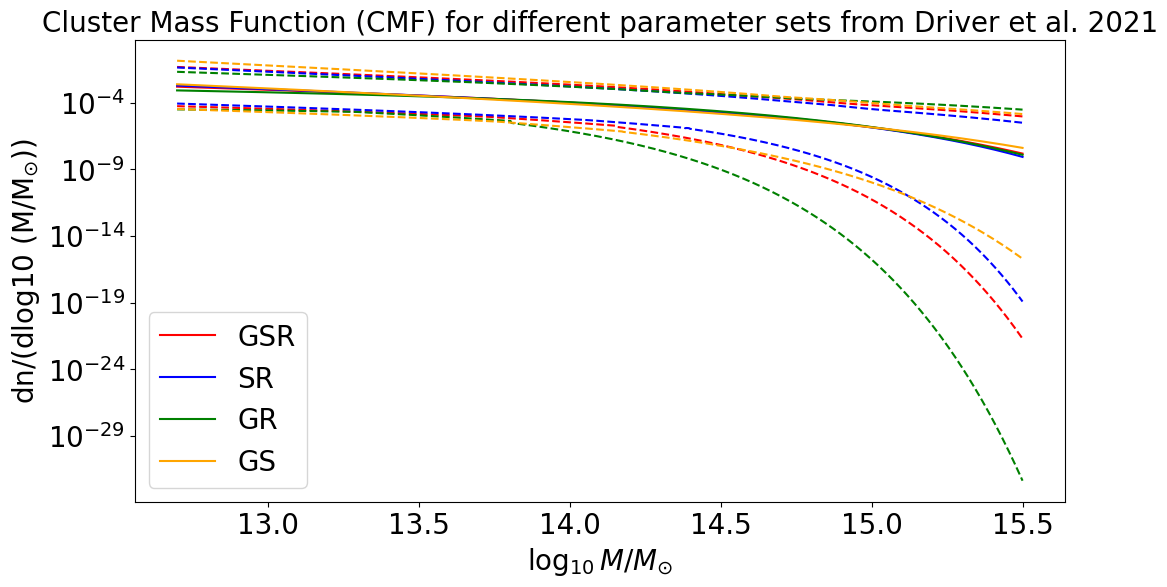

In [12]:
fig = plt.figure(figsize=(12, 6))

cmf_dict = {
    'GSR': {'cmf': CMF_GSR, 'min': Borne_min_CMF_GSR, 'max': Borne_max_CMF_GSR, 'color': 'red'},
    'SR':  {'cmf': CMF_SR,  'min': Borne_min_CMF_SR,  'max': Borne_max_CMF_SR,  'color': 'blue'},
    'GR':  {'cmf': CMF_GR,  'min': Borne_min_CMF_GR,  'max': Borne_max_CMF_GR,  'color': 'green'},
    'GS':  {'cmf': CMF_GS,  'min': Borne_min_CMF_GS,  'max': Borne_max_CMF_GS,  'color': 'orange'}
}

for label, vals in cmf_dict.items():
    plt.plot(log10_M_Msun, vals['cmf'], label=label, color=vals['color'])
    plt.plot(log10_M_Msun, vals['min'], color=vals['color'], linestyle='dashed')
    plt.plot(log10_M_Msun, vals['max'], color=vals['color'], linestyle='dashed')

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')
plt.yscale('log')
plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')
plt.legend()


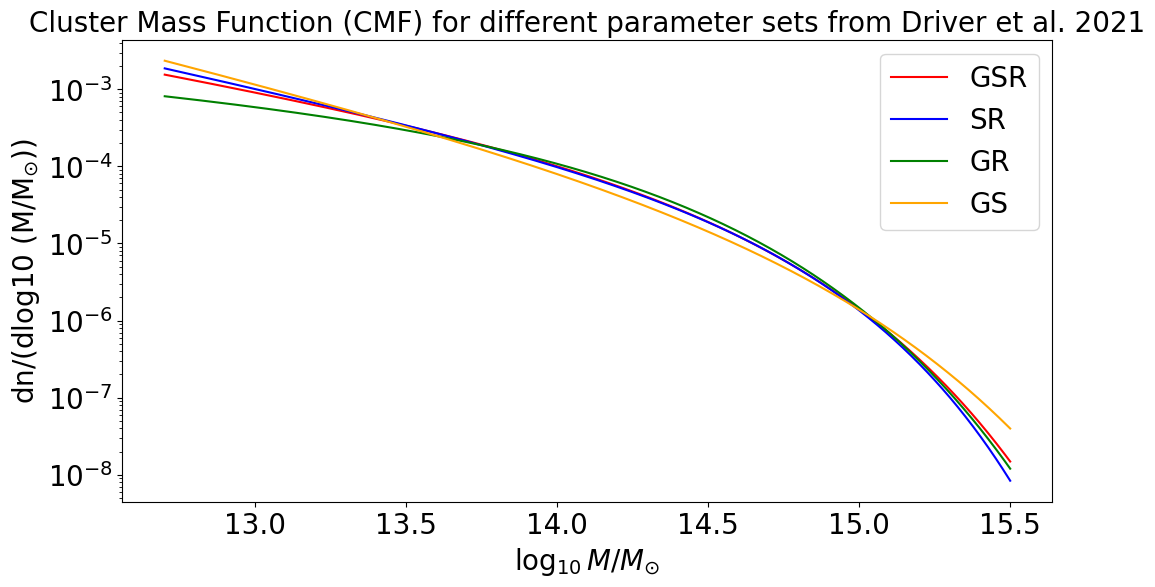

In [13]:
fig = plt.figure(figsize=(12, 6))

cmf_curves = [
    (log10_M_Msun, CMF_GSR, 'GSR', 'red'),
    (log10_M_Msun, CMF_SR,  'SR',  'blue'),
    (log10_M_Msun, CMF_GR,  'GR',  'green'),
    (log10_M_Msun, CMF_GS,  'GS',  'orange')
]

for x, y, label, color in cmf_curves:
    plt.plot(x, y, label=label, color=color)

plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')
plt.yscale('log')
plt.title('Cluster Mass Function (CMF) for different parameter sets from Driver et al. 2021')
plt.legend()

## Calcul volumes relevés +  nombre d'amas

In [14]:
# ATTENTION : calcul ci desoous PAS VALABLE car la mean density correspond à celle à z = 0.1 → On néglige cependant POUR l'INSTANT l'effet d'évolution de la CMF avec z 

# Nombre théorique d'amas dans le volume couvert par divers catalogues : pour l'instant DESI Legacy Imaging Surveys (Wen et Han 2024) ; SCUSS (Gao et al. 2019)
bornes_z = [0,0.65] # Bornes de redshift pour lesquelles on calcule le nombre d'amas (DESI Legacy va jusqu'à z = 1.5)

bornes_log10_M_Msun = [12.7,15.5] # Bornes de masses pour lesquelles la fonction MRP est valable 

## Densité volumique moyenne de la CMF théorique selon les différents lots de paramètres

mean_density_GSR = CMF_to_mean_density(CMF_GSR_func,bornes_log10_M_Msun)
mean_density_SR = CMF_to_mean_density(CMF_SR_func,bornes_log10_M_Msun)
mean_density_GR = CMF_to_mean_density(CMF_GR_func,bornes_log10_M_Msun)
mean_density_GS = CMF_to_mean_density(CMF_GS_func,bornes_log10_M_Msun)


## DESI Legacy Imaging Surveys

angular_area_DESI_deg2 = 24000 # Surface couverte par DESI Legacy Imaging Surveys en degrés carrés
volume_DESI_LEGACY = Volume_survey(angular_area_DESI_deg2,bornes_z) # Volume en Mpc^3 de la zone couverte par DESI Legacy Imaging Surveys (oon coupe en fait à 0.65 alors que ce relevé va jusqu'à 1.5, et on utilise la distance de diamètre angualaire pour la profondeur)
# GSR / DESI
N_GSR_DESI = mean_density_GSR * volume_DESI_LEGACY # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_DESI = ',round(N_GSR_DESI/1e6,3),'* 1e6 amas')
# SR / DESI
N_SR_DESI = mean_density_SR * volume_DESI_LEGACY 
print('N_SR_DESI = ',round(N_SR_DESI/1e6,3),'* 1e6 amas')
# GR / DESI
N_GR_DESI = mean_density_GR * volume_DESI_LEGACY
print('N_GR_DESI = ',round(N_GR_DESI/1e6,3),'* 1e6 amas')
# GS / DESI
N_GS_DESI = mean_density_GS * volume_DESI_LEGACY
print('N_GS_DESI = ',round(N_GS_DESI/1e6,3),'* 1e6 amas\n')



## SCUSS/SDSS/unWISE
bornes_z_SCUSS = [0.05,0.65]
angular_area_SCUSS_deg2 = 3700 # Surface couverte par SCUSS/SDSS/unWISE en degrés carrés
volume_SCUSS = Volume_survey(angular_area_SCUSS_deg2,bornes_z_SCUSS)
# GSR / SCUSS
N_GSR_SCUSS = mean_density_GSR * volume_SCUSS # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_SCUSS = ',round(N_GSR_SCUSS/1e6,3),'* 1e6 amas')
# SR / eRASS1
N_SR_SCUSS = mean_density_SR * volume_SCUSS 
print('N_SR_SCUSS = ',round(N_SR_SCUSS/1e6,3),'* 1e6 amas')
# GR / SCUSS
N_GR_SCUSS = mean_density_GR * volume_SCUSS
print('N_GR_SCUSSI = ',round(N_GR_SCUSS/1e6,3),'* 1e6 amas')
# GS / SCUSS
N_GS_SCUSS = mean_density_GS * volume_SCUSS
print('N_GS_SCUSS = ',round(N_GS_SCUSS/1e6,3),'* 1e6 amas\n')


## eRASS1
angular_area_eRASS1_deg2 = 13116 # Surface couverte par eRASS1/SDSS/unWISE en degrés carrés
volume_eRASS1 = Volume_survey(angular_area_eRASS1_deg2,bornes_z)
# GSR / eRASS1
N_GSR_eRASS1 = mean_density_GSR * volume_eRASS1 # Ce serait bien aussi de prendre en compte les erreurs pour avoir une fourchette de valeurs
print('N_GSR_eRASS1 = ',round(N_GSR_eRASS1/1e6,3),'* 1e6 amas')
# SR / eRASS1
N_SR_eRASS1 = mean_density_SR * volume_eRASS1 
print('N_SR_eRASS1 = ',round(N_SR_eRASS1/1e6,3),'* 1e6 amas')
# GR / eRASS1
N_GR_eRASS1 = mean_density_GR * volume_eRASS1
print('N_GR_eRASS1 = ',round(N_GR_eRASS1/1e6,3),'* 1e6 amas')
# GS / eRASS1
N_GS_eRASS1 = mean_density_GS * volume_eRASS1
print('N_GS_eRASS1 = ',round(N_GS_eRASS1/1e6,3),'* 1e6 amas')


N_GSR_DESI =  27.215 * 1e6 amas
N_SR_DESI =  29.846 * 1e6 amas
N_GR_DESI =  19.3 * 1e6 amas
N_GS_DESI =  32.938 * 1e6 amas

N_GSR_SCUSS =  4.193 * 1e6 amas
N_SR_SCUSS =  4.598 * 1e6 amas
N_GR_SCUSSI =  2.973 * 1e6 amas
N_GS_SCUSS =  5.074 * 1e6 amas

N_GSR_eRASS1 =  14.873 * 1e6 amas
N_SR_eRASS1 =  16.311 * 1e6 amas
N_GR_eRASS1 =  10.548 * 1e6 amas
N_GS_eRASS1 =  18.001 * 1e6 amas


# Comparaison avec les catalogues

## DESI Legacy Imaging surveys

In [15]:
path_DESI = '../SCUSS_DESI/DESI_Legacy_Wen_2024.fit'
table_DESI = fits_to_dataframe(path_DESI)

In [16]:
table_DESI

,_RAJ2000,_DEJ2000,ID,n_Name,Name,RAJ2000,DEJ2000,zCl,f_zCl,zmag,...,logMs,r500,lam500,M500,Ngal,Gamma,e_Gamma,imag_,Cat,recno
0,0.00046,-37.47628,1,,J000000.1-372835,0.00046,-37.47628,0.1364,0,15.377,...,11.49,0.766,25.79,1.17,14,0.0,0.0,1,WHY18,1
1,0.00135,-56.58835,2,WH-,J000000.3-563518,0.00135,-56.58835,0.1957,0,15.712,...,11.70,0.625,23.24,1.06,7,0.0,0.0,1,,2
2,0.00172,-39.32369,3,,J000000.4-391925,0.00172,-39.32369,0.3580,0,17.713,...,11.41,0.526,15.90,0.73,7,0.0,0.0,1,Y21,3
3,0.00201,2.31980,4,,J000000.5+021911,0.00201,2.31980,0.4282,1,18.043,...,11.55,0.612,23.40,1.07,13,0.0,0.0,1,redMaPPer,4
4,0.00260,-59.01297,5,WH-,J000000.6-590047,0.00260,-59.01297,0.1380,0,14.993,...,11.69,0.606,15.71,0.73,7,0.0,0.0,1,,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581174,359.99667,4.99211,1581175,WH-,J235959.2+045932,359.99667,4.99211,0.5948,0,19.184,...,11.37,0.420,10.99,0.51,6,0.0,0.0,2,,1581175
1581175,359.99680,21.78514,1581176,,J235959.2+214707,359.99680,21.78514,0.4050,1,17.259,...,11.78,0.658,31.73,1.43,9,0.0,0.0,2,WHL,1581176
1581176,359.99817,10.04951,1581177,,J235959.6+100258,359.99817,10.04951,0.7919,0,18.904,...,11.88,0.621,33.23,1.50,8,0.0,0.0,2,CFSFDP,1581177
1581177,359.99847,-6.34469,1581178,WH-,J235959.6-062041,359.99847,-6.34469,1.0333,0,20.952,...,11.18,0.439,13.12,0.61,6,0.0,0.0,2,,1581178


In [17]:
table_DESI.columns

Index(['_RAJ2000', '_DEJ2000', 'ID', 'n_Name', 'Name', 'RAJ2000', 'DEJ2000',
       'zCl', 'f_zCl', 'zmag', 'W1mag', 'logMs', 'r500', 'lam500', 'M500',
       'Ngal', 'Gamma', 'e_Gamma', 'imag_', 'Cat', 'recno'],
      dtype='object')

In [18]:
# Nombre d'amas compris entre les bornes de z utilisés pour le calcul du nombre d'amas à partir de la CMF théorique
N_amas_DESI = len(table_DESI[(table_DESI['zCl'] >= bornes_z[0]) & (table_DESI['zCl'] <= bornes_z[1])])
print('N_amas_DESI = ',N_amas_DESI)

N_amas_DESI =  821225


In [19]:
# A FAIRE → DISTRIBUTION AMAS LUMINOSITE + COULEUR REDSHIFT ...

In [20]:
M500_DESI = np.log10(np.array(table_DESI['M500'])*1e14)
M500_DESI = M500_DESI[(M500_DESI > 12.7) & (M500_DESI < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

Text(0.5, 1.0, 'Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

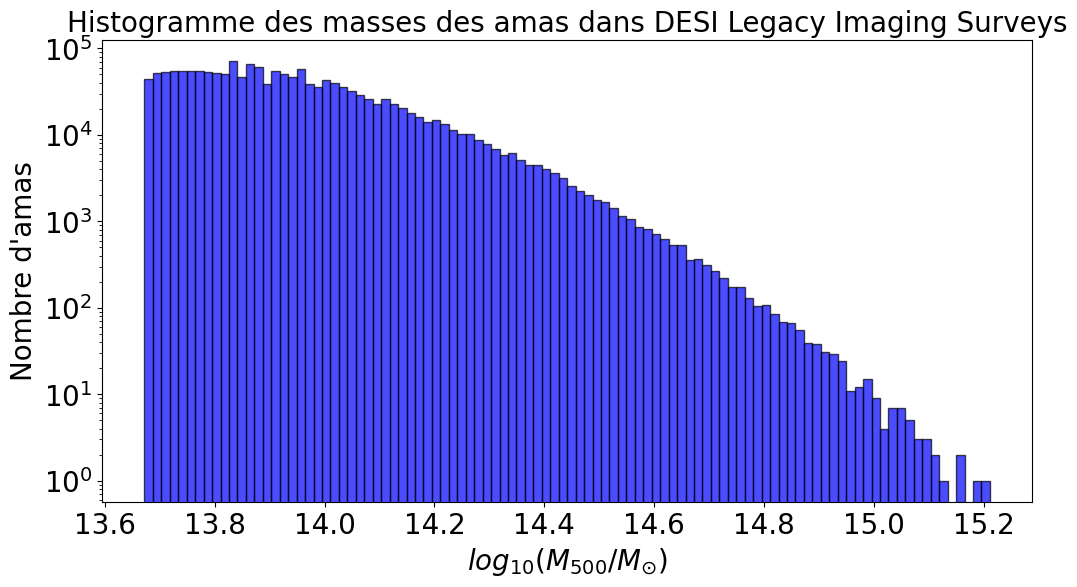

In [21]:
plt.figure(figsize=(12, 6))
plt.hist(M500_DESI, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans DESI Legacy Imaging Surveys')

In [22]:
# Calculate histogram density using our utility function
bin_centers, counts, bin_width_DESI, n_DESI_Legacy = compute_histogram_density(
    data=M500_DESI,
    bins=100,
    volume=volume_DESI_LEGACY)

print("Bin width:", bin_width_DESI)


Bin width: 0.015392896950011448


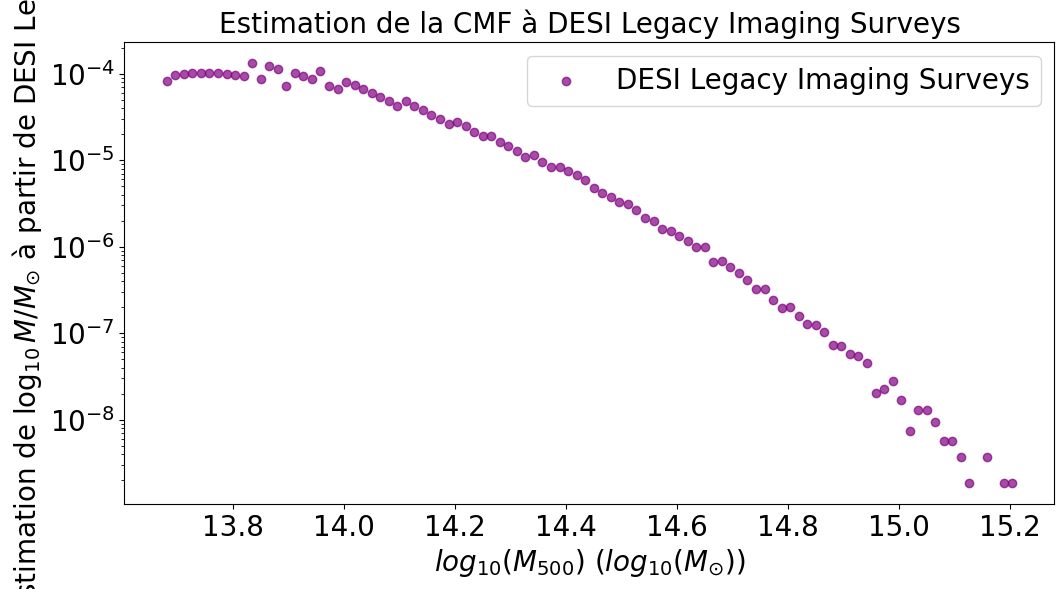

In [23]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de DESI Legacy')
plt.yscale('log')
plt.title('Estimation de la CMF à DESI Legacy Imaging Surveys')
plt.legend()

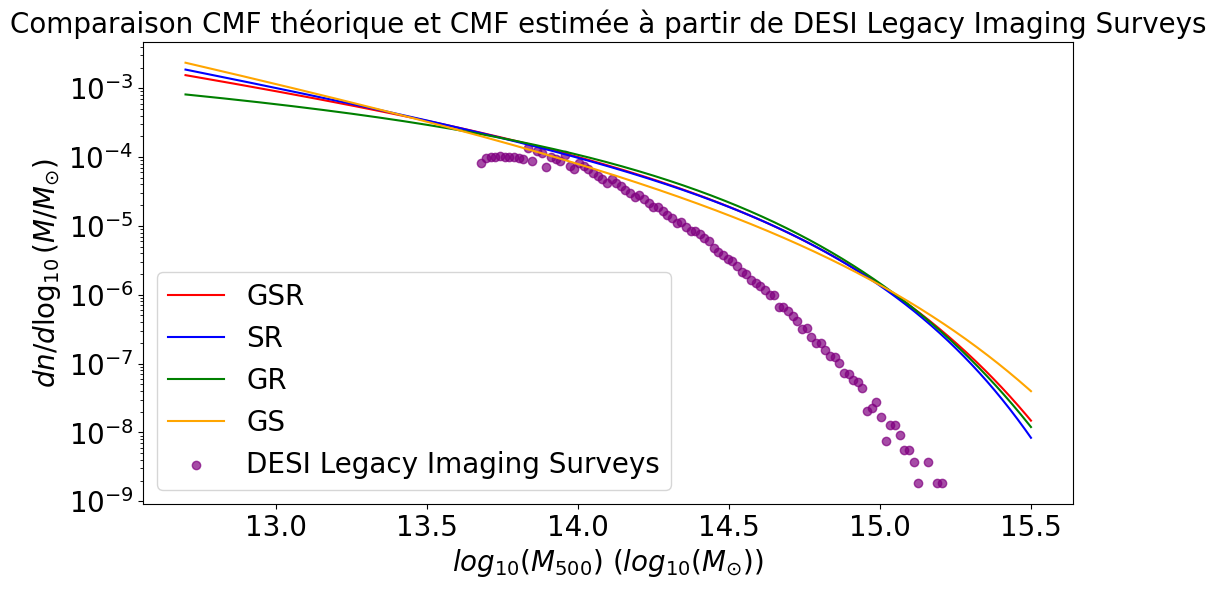

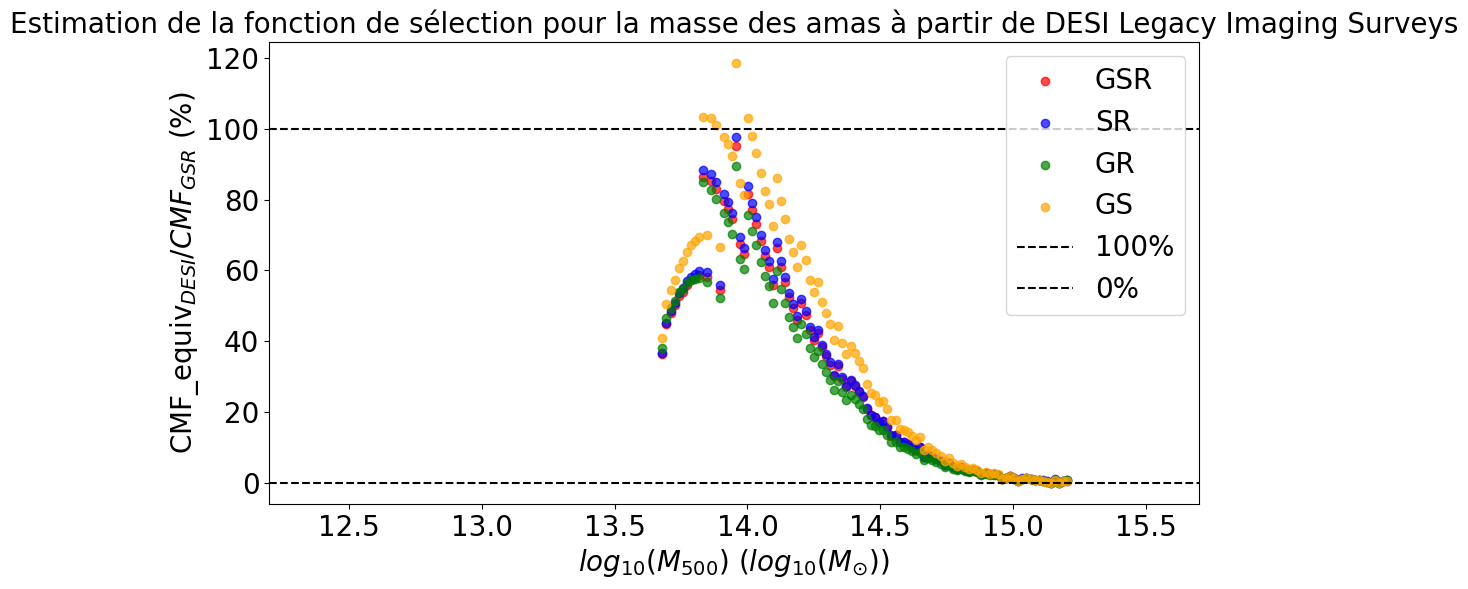

In [24]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} (M / M_{\odot})$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')

plt.legend()

#---------------------------------------------------------------------------------------------
# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_DESI_Legacy/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_DESI_Legacy/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_DESI_Legacy/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_DESI_Legacy/CMF_GS_func(bin_centers)


plt.figure(figsize=(12, 6))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')
plt.xlim(12.2, 15.7)

plt.hlines(100, 12.2, 15.7, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.2, 15.7, color='black', linestyle='dashed', label='0%')


plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{DESI} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de DESI Legacy Imaging Surveys')

plt.legend()


plt.legend()

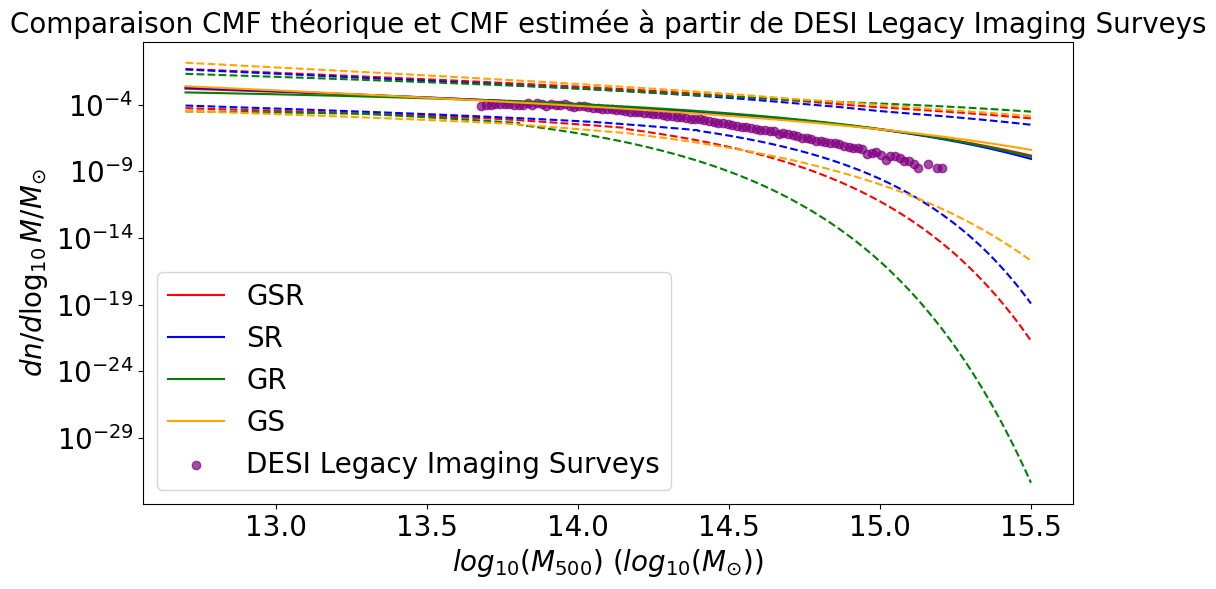

In [25]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_DESI_Legacy, color='purple', label='DESI Legacy Imaging Surveys', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()

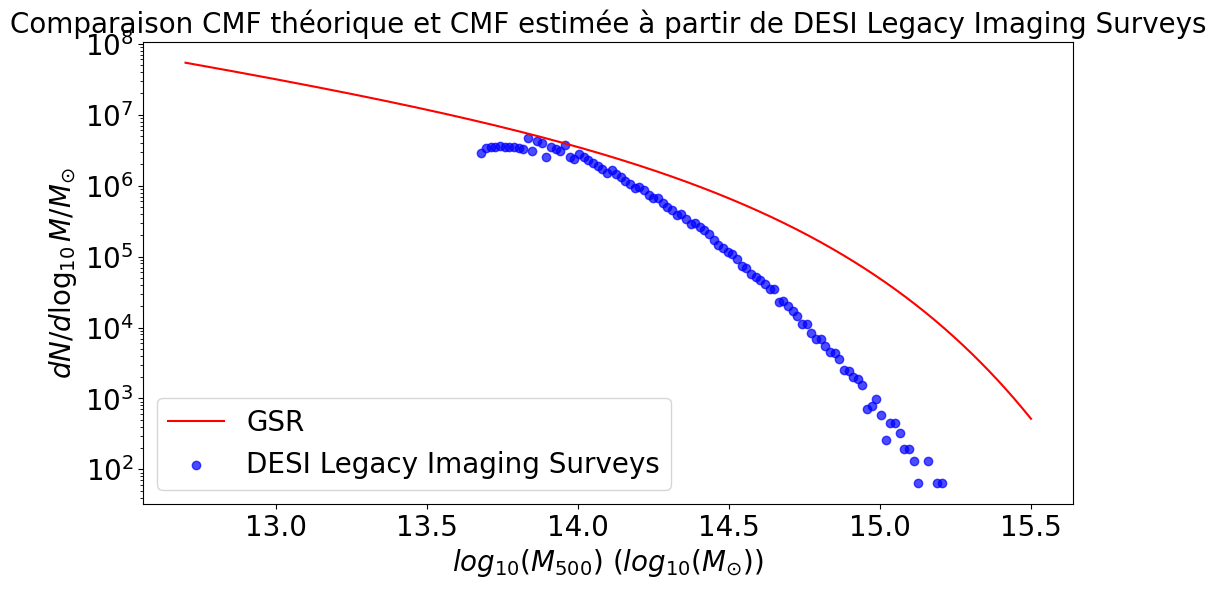

In [26]:
# dex ^-1

fig = plt.figure(figsize=(12, 6))
plt.plot(log10_M_Msun, CMF_GSR*volume_DESI_LEGACY, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_DESI, color='blue', label='DESI Legacy Imaging Surveys', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dN / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de DESI Legacy Imaging Surveys')
plt.legend()


## SCUSS

In [27]:
#SCUSS
path_SCUSS = '../SCUSS_DESI/SCUSS_Gao_2020.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_SCUSS = fits_to_dataframe(path_SCUSS)

zSCUSS_list = []
for idx, row in table_SCUSS.iterrows():
    if row[f'zsp'] == 0:
        zSCUSS_list.append(row[f'zph'])
    else:
        zSCUSS_list.append(row[f'zsp'])
table_SCUSS['z'] = zSCUSS_list

In [28]:
# On découpe la table en différents bins de z contenant le même nombre d'amas
nb_bins_z = 3
table_SCUSS['z_bin'], bornes_z_SCUSS = pd.qcut(table_SCUSS['z'], q=nb_bins_z, retbins=True, labels=False)
print('Bornes de z pour les bins SCUSS : ', bornes_z_SCUSS)

# Create subtables for each bin
subtables_z_SCUSS = []
for i in range(nb_bins_z):
    subtable = table_SCUSS[table_SCUSS['z_bin'] == i]
    print(f'bin {i}: z from {round(bornes_z_SCUSS[i],3)} to {round(bornes_z_SCUSS[i+1],3)}, count={len(subtable)}')
    subtables_z_SCUSS.append(subtable)

Bornes de z pour les bins SCUSS :  [0.0503     0.28770333 0.39967667 0.6299    ]
bin 0: z from 0.05 to 0.288, count=6537
bin 1: z from 0.288 to 0.4, count=6536
bin 2: z from 0.4 to 0.63, count=6537


In [29]:
table_SCUSS.columns

Index(['_RAJ2000', '_DEJ2000', 'Name', 'RAJ2000', 'DEJ2000', 'zph', 'zsp',
       'zphmedian', 'N1Mpc', 'L1Mpc', 'Richness', 'M500', 'recno', 'z',
       'z_bin'],
      dtype='object')

### Fonction de masse

#### Récupération / Calculs valeurs

In [30]:
M500_SCUSS = np.log10(np.array(table_SCUSS['M500'])*1e14)
M500_SCUSS = M500_SCUSS[(M500_SCUSS > 12.7) & (M500_SCUSS < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

In [31]:
# Calculate histogram density using our utility function
bin_centers, counts, bin_width_SCUSS, n_SCUSS = compute_histogram_density(
    data=M500_SCUSS,
    bins=100,
    volume=volume_SCUSS
)

print("Bin width:", bin_width_SCUSS)

Bin width: 0.024221519325980267


In [32]:
# Estimation de la fonction de sélection pour la masse des amas

estimation_selection_function_masse_GSR = n_SCUSS/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_SCUSS/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_SCUSS/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_SCUSS/CMF_GS_func(bin_centers)

#### Tracés

Text(0.5, 1.0, 'Histogramme des masses des amas dans SCUSS')

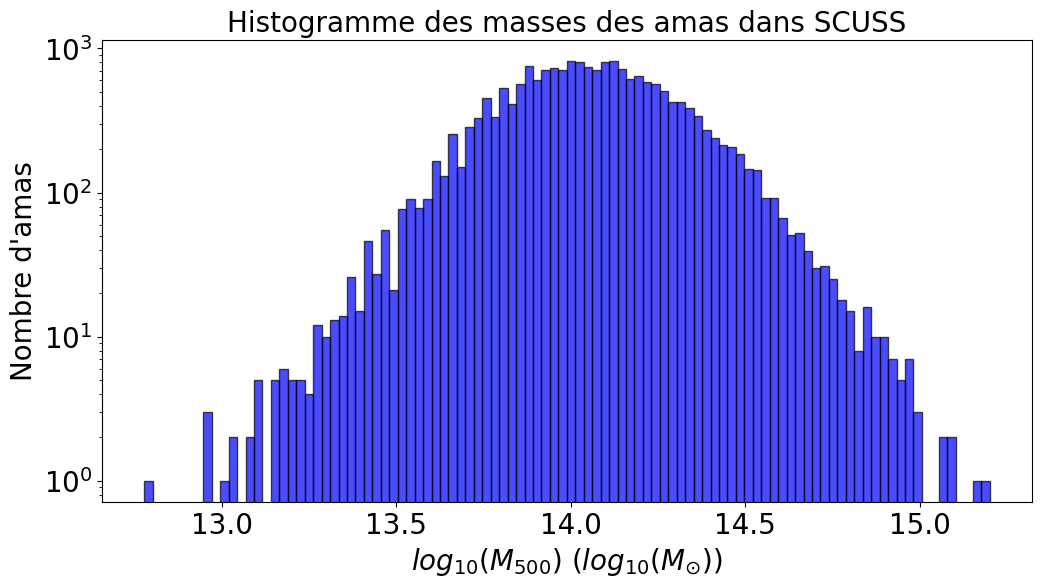

In [33]:
plt.figure(figsize=(12, 6))
plt.hist(M500_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans SCUSS')

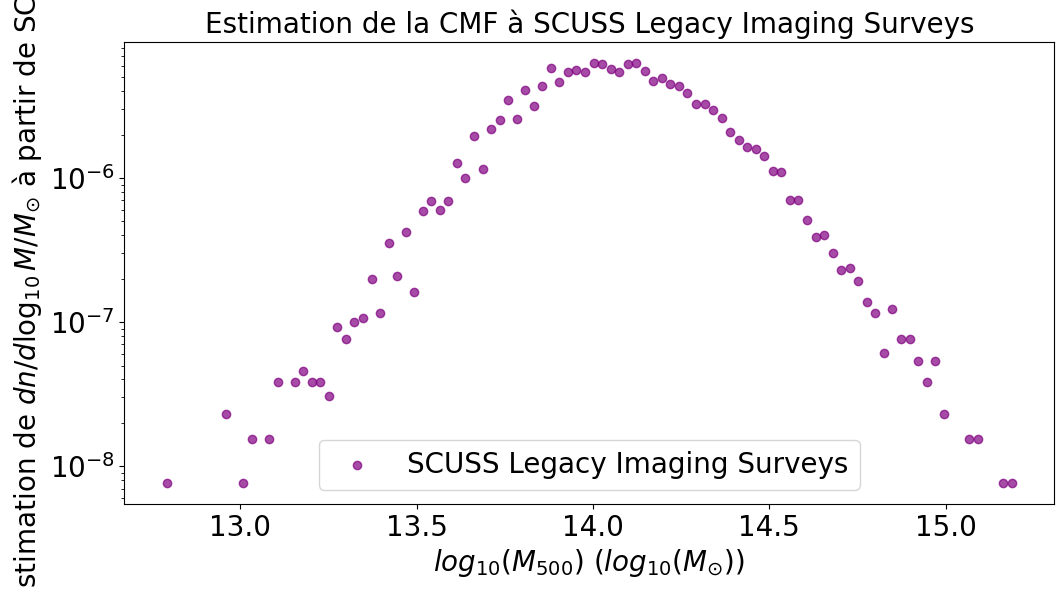

In [34]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS Legacy Imaging Surveys', alpha=0.7) 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $dn / d\log_{10} M / M_{\odot}$ à partir de SCUSS')
plt.yscale('log')
plt.title('Estimation de la CMF à SCUSS Legacy Imaging Surveys')
plt.legend()

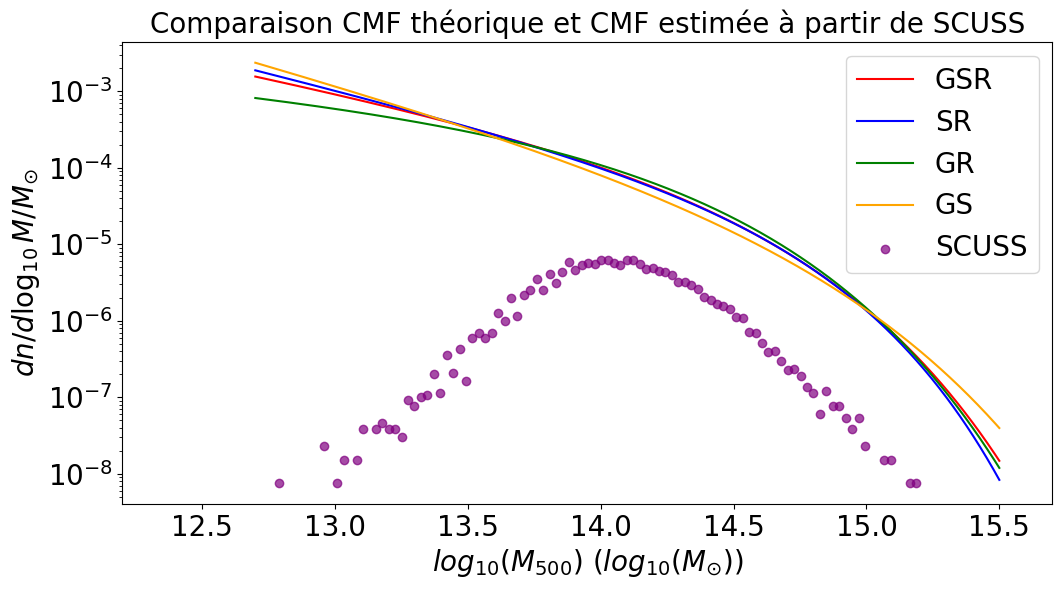

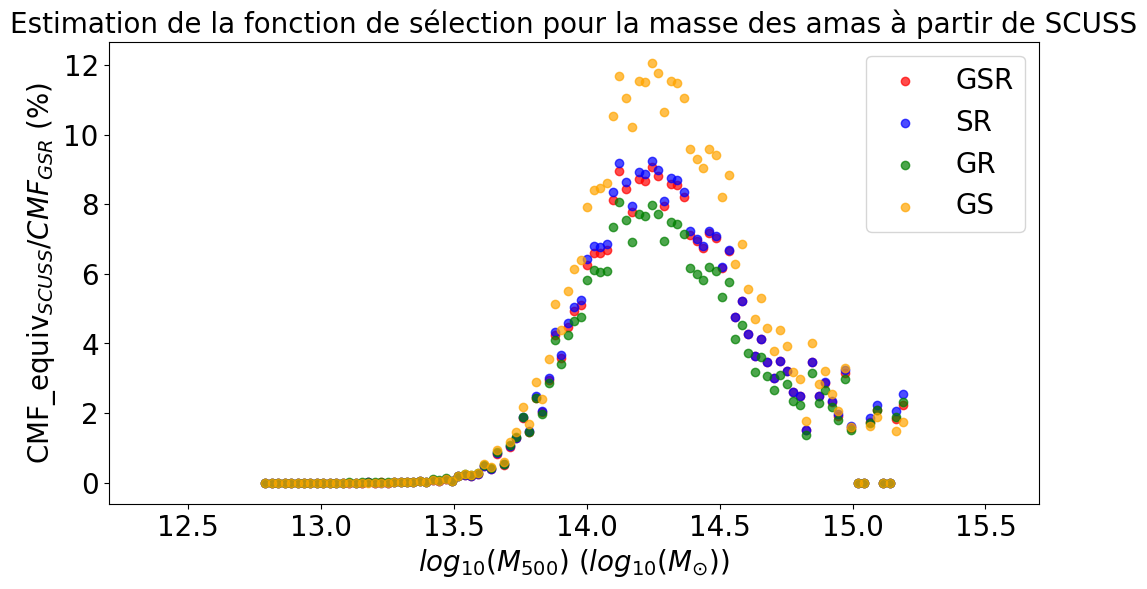

In [35]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

#-------------------------------------
fig1 = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)
plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')

plt.legend()

#-------------------------------------

plt.figure(figsize=(12, 6))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

plt.xlim(12.2, 15.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS')

plt.legend()

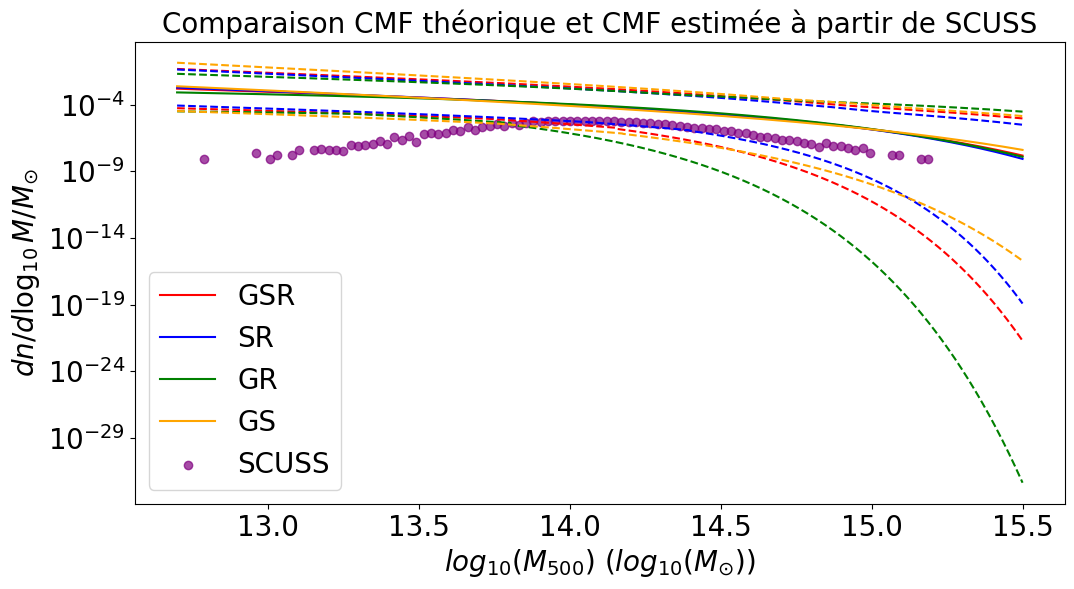

In [36]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(12, 6))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_SCUSS, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de SCUSS')
plt.legend()

### Fonction de "richesse"

#### Récupération / Calculs valeurs

In [37]:
RL_SCUSS = table_SCUSS['Richness'] # On récupère les données sur la richesse des amas

In [38]:
bin_centers_RL, counts_RL, bin_width_SCUSS_RL, n_SCUSS_RL = compute_histogram_density(RL_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width RL :", bin_width_SCUSS_RL)

Bin width RL : 2.3848826


In [39]:
# Calculs des CRF (Cluster Richness Function) théoriques
array_RL_SCUSS = np.linspace(np.min(RL_SCUSS), np.max(RL_SCUSS), 1000) # RL

CRF_MRP_GSR_func = CRF_MRP(params_GSR) # "CRF" pour Cluster Richness Function → MRP car tirée de la CMF MRP 
CRF_MRP_SR_func = CRF_MRP(params_SR)
CRF_MRP_GR_func = CRF_MRP(params_GR)
CRF_MRP_GS_func = CRF_MRP(params_GS)

CRF_MRP_GSR_result = CRF_MRP_GSR_func(array_RL_SCUSS)
CRF_MRP_GSR = CRF_MRP_GSR_result[0]
CMF_GSR_from_RL_SCUSS_min = CRF_MRP_GSR_result[1]
CMF_GSR_from_RL_SCUSS_max = CRF_MRP_GSR_result[2]

bin_centers_log10_M_Msun_from_RL_SCUSS = RL_to_log10_M_Msun(bin_centers_RL)[0]
CRF_MRP_GSR_result_bin_centers = CRF_MRP_GSR_func(bin_centers_log10_M_Msun_from_RL_SCUSS)
CRF_MRP_GSR_bin_centers = CRF_MRP_GSR_result_bin_centers[0]
CMF_GSR_from_RL_SCUSS_min_bin_centers = CRF_MRP_GSR_result_bin_centers[1]
CMF_GSR_from_RL_SCUSS_max_bin_centers = CRF_MRP_GSR_result_bin_centers[2]

# Estimation de la fonction de sélection pour la richesse des amas
estimation_selection_function_RL_SCUSS_GSR = n_SCUSS_RL/CRF_MRP_GSR_bin_centers


#### Tracés

Text(0.5, 1.0, 'Histogramme des richesses des amas dans SCUSS')

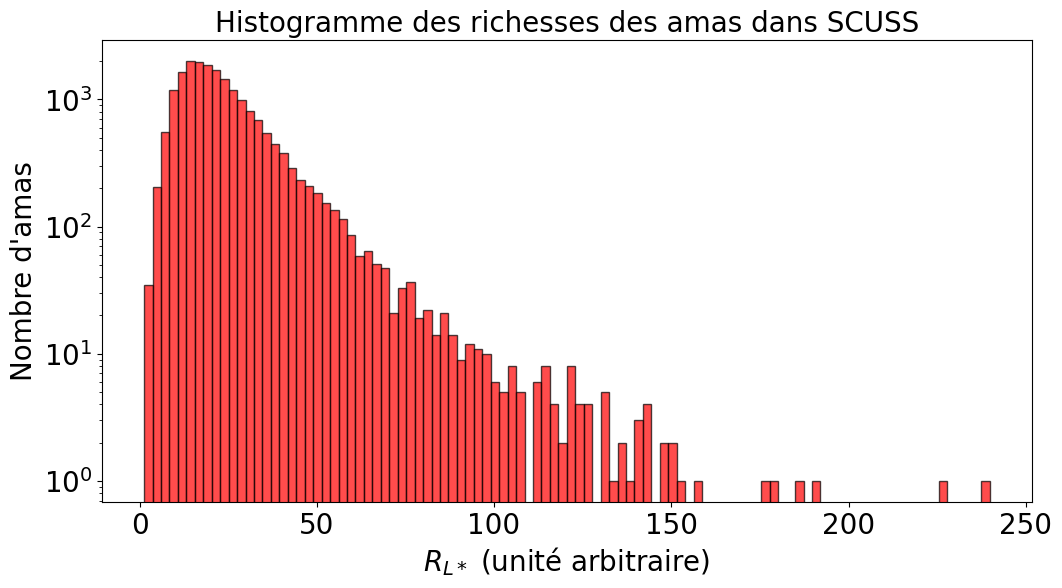

In [40]:
plt.figure(figsize=(12, 6))
plt.hist(RL_SCUSS, bins=100, color='red', edgecolor='black', alpha=0.7)
plt.xlabel(r'$R_{L*}$ (unité arbitraire)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des richesses des amas dans SCUSS')

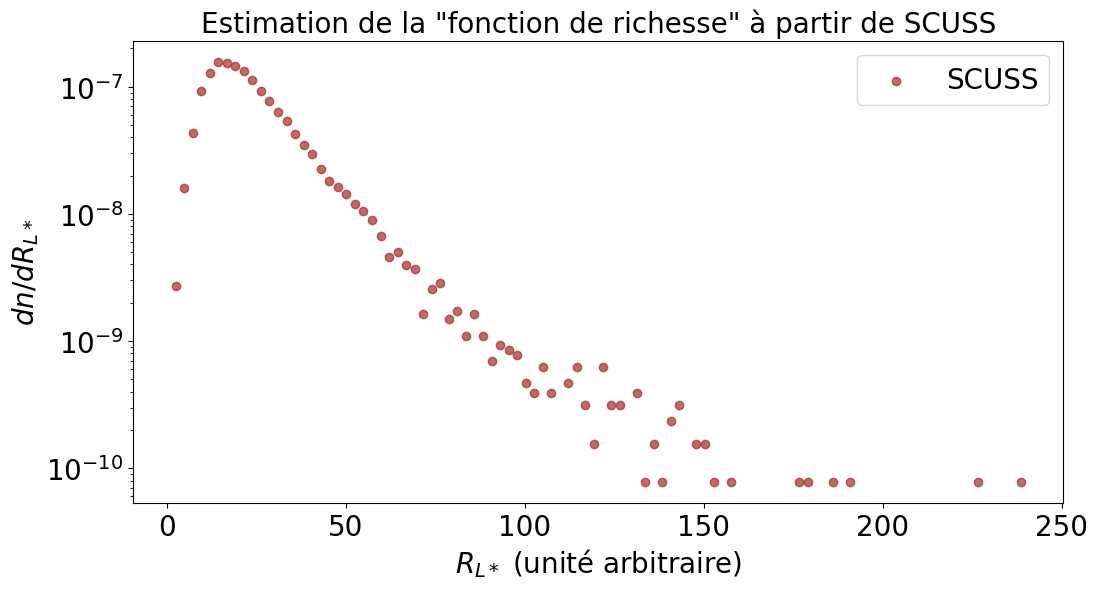

In [41]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_RL, n_SCUSS_RL, color='brown', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$R_{L*}$ (unité arbitraire)')
plt.ylabel(r'$dn / dR_{L*}$')
plt.yscale('log')
plt.title(r'Estimation de la "fonction de richesse" à partir de SCUSS')
plt.legend()

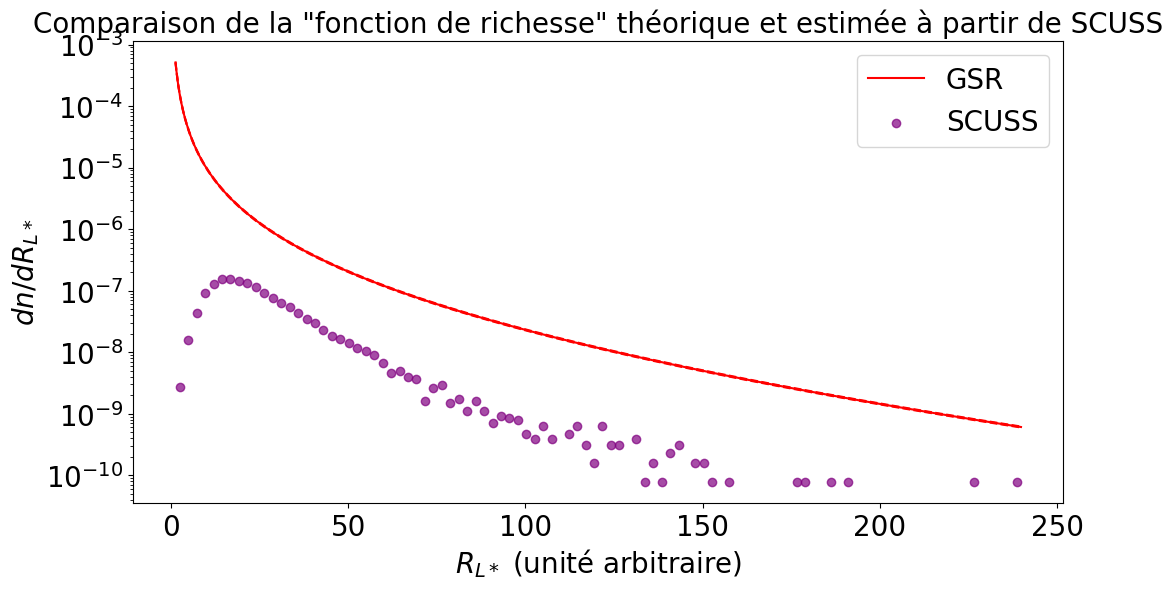

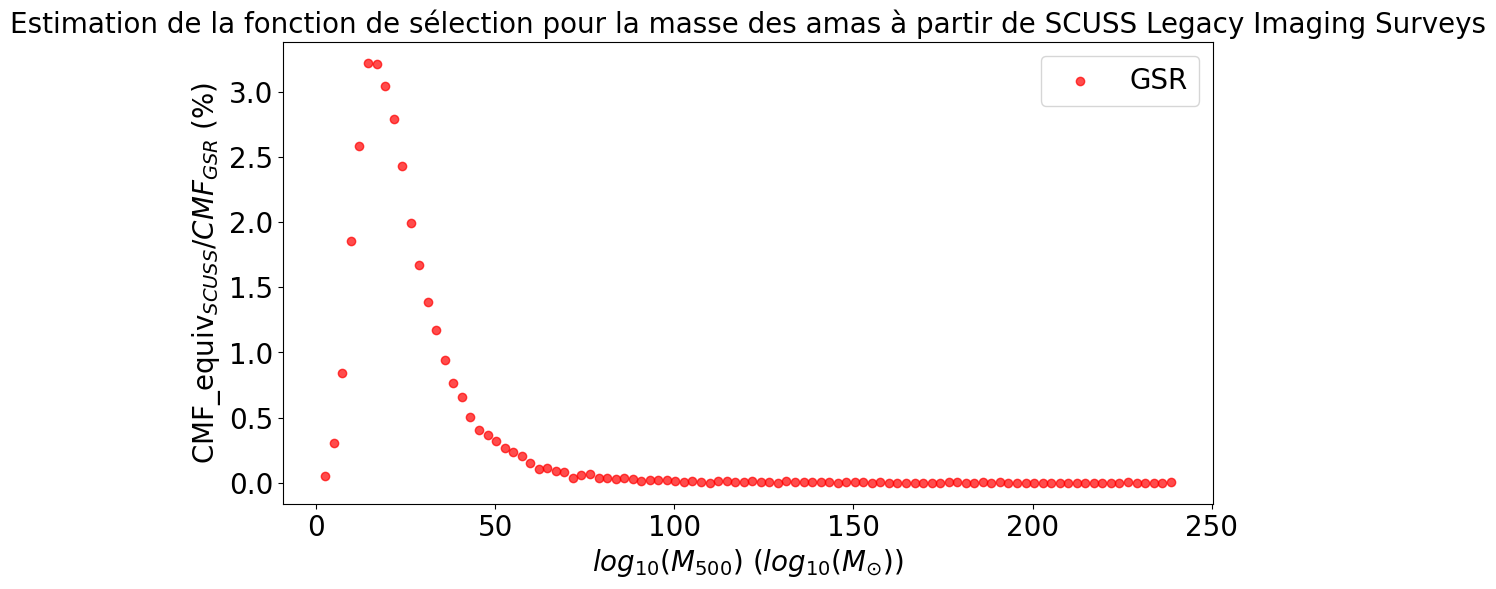

In [42]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(12, 6))

plt.plot(array_RL_SCUSS, CRF_MRP_GSR, label='GSR', color='red')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_min, color='red',linestyle='dashed')
plt.plot(array_RL_SCUSS, CMF_GSR_from_RL_SCUSS_max, color='red',linestyle='dashed')

plt.scatter(bin_centers_RL, n_SCUSS_RL, color='purple', label='SCUSS', alpha=0.7)

plt.xlabel(r'$R_{L*}$ (unité arbitraire)',fontsize=20)
plt.ylabel(r'$dn / dR_{L*}$',fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.yscale('log')
plt.title(r'Comparaison de la "fonction de richesse" théorique et estimée à partir de SCUSS',fontsize=20)

plt.legend(fontsize=20)

#-------------------------------------

plt.figure(figsize=(12, 6))

plt.scatter(bin_centers_RL, estimation_selection_function_RL_SCUSS_GSR * 100, color='red', alpha=0.7,label='GSR')
'''plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')'''

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{SCUSS} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de SCUSS Legacy Imaging Surveys')

plt.legend()

### Fonction de luminosité

#### L1Mpc - Luminosité absolue en bande r

#### Récupération / Calculs valeurs

In [46]:
# Données SCUSS : L1Mpc :

L1MPC_SCUSS = table_SCUSS['L1Mpc'] # Gao et al. 2019, section 3.3 : "L1Mpc is the total r-band luminosity of cluster members within a distance of 1 Mpc from the BCG"
log10_L1MPC_SCUSS = np.log10(L1MPC_SCUSS) # Calcul possible car L1Mpc est adimensionné (exprimé en unités de L*, lumisnoisté de référence d'une galaxie)

bin_centers_L1Mpc, counts_L1Mpc, bin_width_SCUSS_L1Mpc, n_SCUSS_L1Mpc = compute_histogram_density(L1MPC_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width L1Mpc:", bin_width_SCUSS_L1Mpc)

bin_centers_L1Mpc_log10, counts_L1Mpc_log10, bin_width_SCUSS_L1Mpc_log10, n_SCUSS_L1Mpc_log10 = compute_histogram_density(log10_L1MPC_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width L1Mpc:", bin_width_SCUSS_L1Mpc)

Bin width L1Mpc: 0.3860154
Bin width L1Mpc: 0.3860154


In [47]:
bins_mean_z = [] # Je vais y placer les valeurs moyennes de z pour chaque bin de luminosité, afin de pouvoir les positionner sur l'axe des redshifts dans le graphe 3D
for i in range(len(bin_centers_L1Mpc)):
    current_table_SCUSS = table_SCUSS[
        (table_SCUSS['L1Mpc'] >= (bin_centers_L1Mpc[i]-(1/2)*bin_width_SCUSS_L1Mpc)) &
        (table_SCUSS['L1Mpc'] < (bin_centers_L1Mpc[i]+(1/2)*bin_width_SCUSS_L1Mpc))
    ]
    current_mean_z = current_table_SCUSS['z'].mean()
    bins_mean_z.append(current_mean_z)

In [48]:
# Théorie fonction de luminosité

array_L1Mpc_SCUSS = np.linspace(np.min(L1MPC_SCUSS), np.max(L1MPC_SCUSS), 100) # L1Mpc
array_log10_L1Mpc_SCUSS = np.log10(array_L1Mpc_SCUSS) 
array_z = np.array([0.1,0.2,0.3,0.4,0.5,0.6]) # On va faire plusieurs tracés en fonction de plusieurs redshifts
array_z_3D = np.linspace(bornes_z[0], bornes_z[1], 1000) # Pour le graphe 3D

# Calcul de (dn /dlog10(L1Mpc))(log10(L1Mpc)) 
# 2D
CLF_log10_MRP_GSR_func = CLF_log10_MRP(params_GSR,array_z)
CLF_log10_MRP_GSR_result = CLF_log10_MRP_GSR_func(array_log10_L1Mpc_SCUSS)
CLF_log10_MRP_GSR = CLF_log10_MRP_GSR_result[0]
CLF_log10_MRP_GSR_from_min = CLF_log10_MRP_GSR_result[1] # on calcule popur la valeur minimale de log10(L1Mpc) autorisée par la dispersion de la relation de scaling
CLF_log10_MRP_GSR_from_max = CLF_log10_MRP_GSR_result[2] # idem mais pour la valeur max

#3D
CLF_log10_MRP_GSR_func_3D = CLF_log10_MRP(params_GSR,array_z_3D)
CLF_log10_MRP_GSR_result_3D = CLF_log10_MRP_GSR_func_3D(array_log10_L1Mpc_SCUSS)
CLF_log10_MRP_GSR_3D = CLF_log10_MRP_GSR_result_3D[0]

#### Tracés

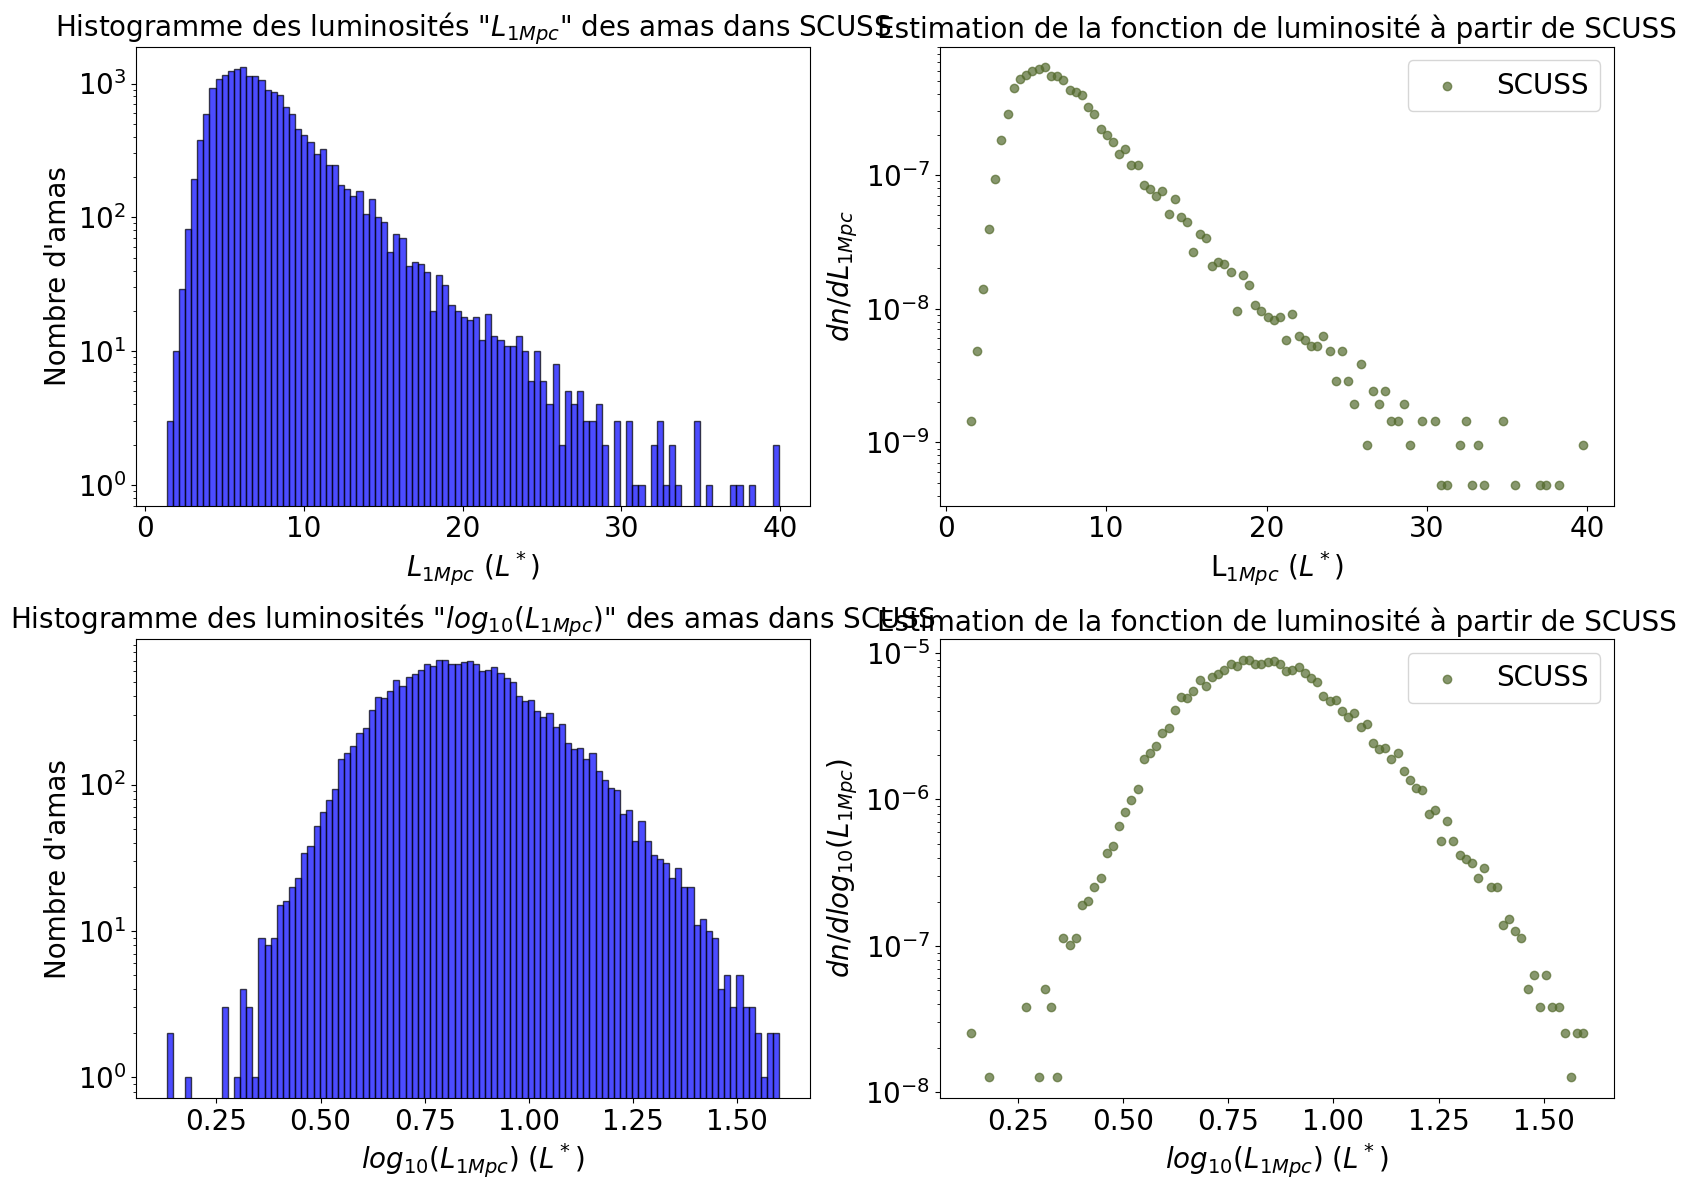

In [49]:
# L1Mpc and log10(L1Mpc) plots as 2x2 subplots

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Histogram L1Mpc
axs[0, 0].hist(L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
axs[0, 0].set_xlabel(r'$L_{1Mpc}$ ($L^*$)')
axs[0, 0].set_ylabel('Nombre d\'amas')
axs[0, 0].set_yscale('log')
axs[0, 0].set_title(r'Histogramme des luminosités "$L_{1Mpc}$" des amas dans SCUSS')

# Top right: dn/dL1Mpc scatter
axs[0, 1].scatter(bin_centers_L1Mpc, n_SCUSS_L1Mpc, color='darkolivegreen', label='SCUSS', alpha=0.7)
axs[0, 1].set_xlabel(r'L$_{1Mpc}$ ($L^*$)')
axs[0, 1].set_ylabel(r'$dn / dL_{1Mpc}$')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
axs[0, 1].legend()

# Bottom left: Histogram log10(L1Mpc)
axs[1, 0].hist(log10_L1MPC_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
axs[1, 0].set_xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
axs[1, 0].set_ylabel('Nombre d\'amas')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r'Histogramme des luminosités "$log_{10}(L_{1Mpc})$" des amas dans SCUSS')

# Bottom right: dn/dlog10(L1Mpc) scatter
axs[1, 1].scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='SCUSS', alpha=0.7)
axs[1, 1].set_xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
axs[1, 1].set_ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


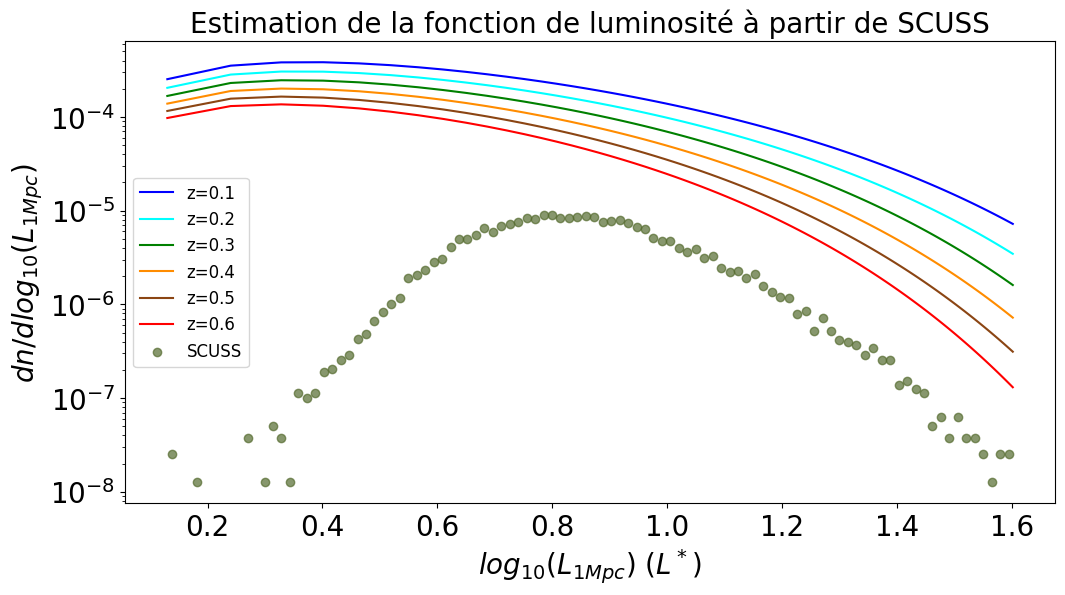

In [50]:
# Mpc ^-3 dex -1
fig1 = plt.figure(figsize=(12, 6))

for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='SCUSS', alpha=0.7)


plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)

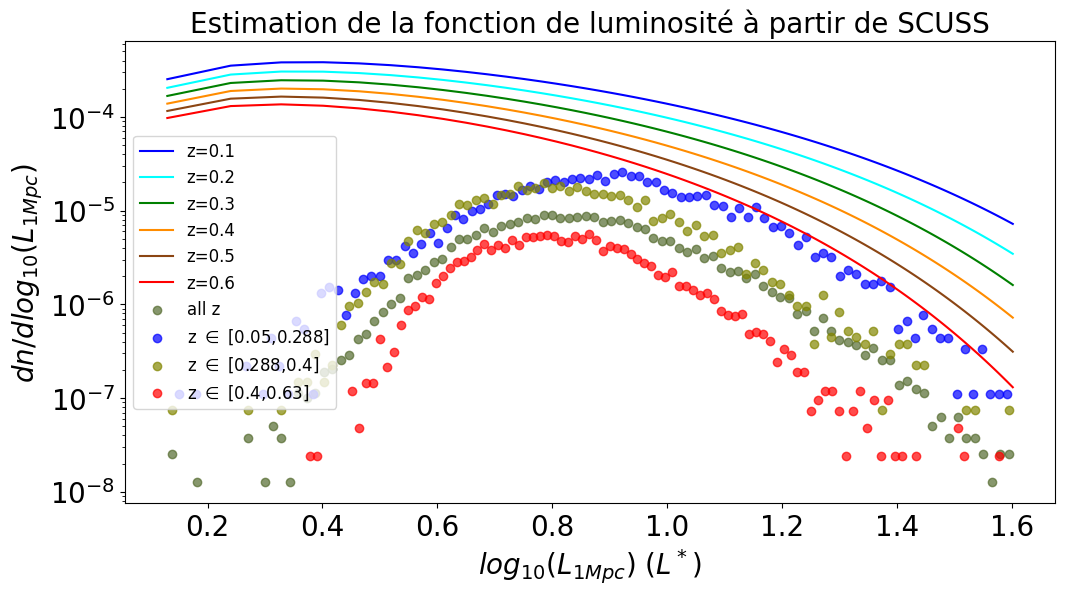

In [55]:
# On fait comme précedemment, mais en s'intéressant aux différents bins de redshift
fig2 = plt.figure(figsize=(12, 6))
#théorie
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i / (len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='darkolivegreen', label='all z', alpha=0.7)
#données
for i,subtable in enumerate(subtables_z_SCUSS):
    L1MPC_subtable = subtable['L1Mpc']
    log10_L1MPC_subtable = np.log10(L1MPC_subtable)
    volume_subtable = Volume_survey(angular_area_SCUSS_deg2,[bornes_z_SCUSS[i],bornes_z_SCUSS[i+1]])

    bin_centers_log10_L1Mpc_subtable, counts_log10_L1Mpc_subtable, bin_width_SCUSS_L1Mpc_log10_subtable, n_SCUSS_log10_L1Mpc_subtable = compute_histogram_density(log10_L1MPC_subtable,
                                                                                                                                                                  bins=100,
                                                                                                                                                                  volume=volume_subtable) 
                                                                                                                                                                  #On considère le voulme compris entre les bornes de redshift
    
    plt.scatter(bin_centers_log10_L1Mpc_subtable,
                n_SCUSS_log10_L1Mpc_subtable,
                label=fr'z $\in$ [{round(bornes_z_SCUSS[i],3)},{round(bornes_z_SCUSS[i+1],3)}]', 
                color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
                alpha=0.7,
                )
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(r'Estimation de la fonction de luminosité à partir de SCUSS')
plt.legend(fontsize=12)
#faire idem en Lapp

Pour le code ci-dessous, ajouter la commande magic "%matplotlib widget" pour rendre le graphe 3D interactif : attention cela fonctionnera pour tout les plots, on doit l'enlever de la cellule et restart le kernel pour revenir à la normale.\
(ne semble pas bien marcher sur Cursor)

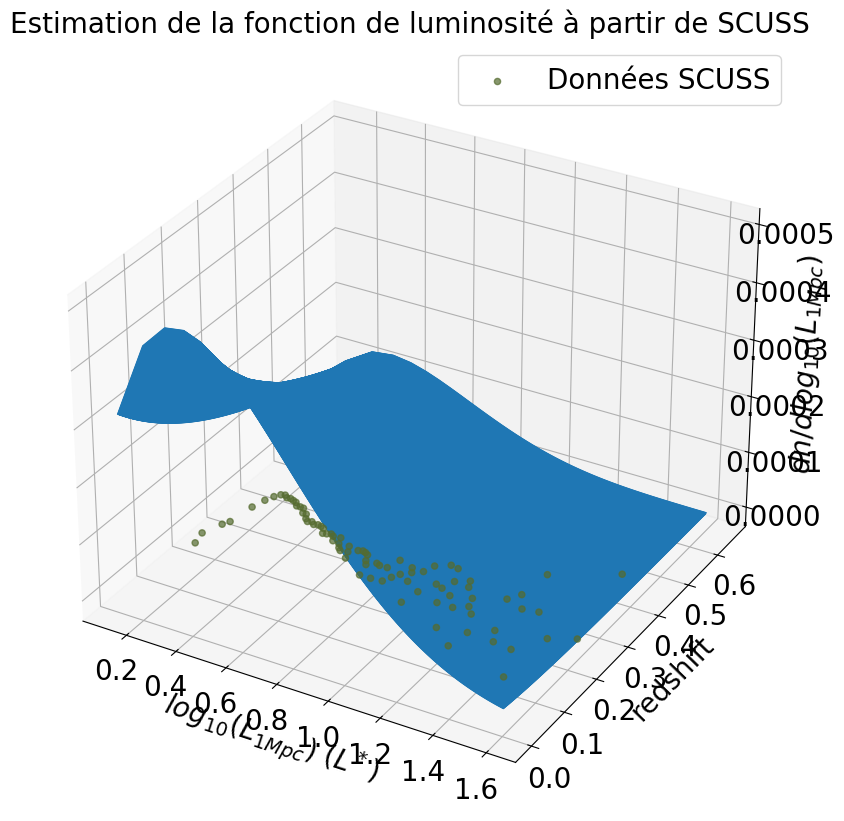

In [52]:
# Idem en 3D
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

for i, z in enumerate(array_z_3D): # On plot dn/dL1Mpc pour chaque redshift
    ax.plot(
        array_log10_L1Mpc_SCUSS,
        array_z_3D[i], # Pour le ième redshift de array_z_3D
        CLF_log10_MRP_GSR_3D[i], # idem
        color='tab:blue'
        #label="Courbes de la fonction de luminosité théorique tirée de la CMF MRP"
    )

ax.scatter(bin_centers_L1Mpc_log10, bins_mean_z, n_SCUSS_L1Mpc_log10, color='darkolivegreen', alpha=0.7, label='Données SCUSS') # !!! bins_mean_z → moyenne en z du bin

#ax.scatter(array_log10_L1Mpc_SCUSS, array_z_3D, CLF_log10_MRP_GSR_3D, cmap='viridis', marker='o')  # c=C pour colorer selon dn/d(log10(M/Msun))
# ajouter les points des données ; réduire l'axe des z à 100
'''
ax.set_zscale('log')
ax.set_zlim(1e-9, 1e-2)  # Adjust these values to fit your data'''

ax.set_xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
ax.set_ylabel('redshift')
ax.set_zlabel(r'$dn / dlog_{10}(L_{1Mpc})$')
ax.legend()
plt.title('Estimation de la fonction de luminosité à partir de SCUSS')
plt.show()

#### Luminosité apparente

##### Calculs

In [54]:
# Add apparent luminosity column to main table
table_SCUSS = add_apparent_luminosity(
    df=table_SCUSS,
    Labs_col='L1Mpc',
    z_col='z',
    cosmo=cosmo,
    new_col='Lapp'
)

# Calculate log10 of apparent luminosity
log10_Lapp_SCUSS = np.log10(table_SCUSS['Lapp'])

# Add apparent luminosity to each subtable
subtables_z_SCUSS = [
    add_apparent_luminosity(
        df=subtable,
        Labs_col='L1Mpc',
        z_col='z',
        cosmo=cosmo,
        new_col='Lapp'
    )
    for subtable in subtables_z_SCUSS
]

bin_centers_Lapp_log10, counts_Lapp_log10, bin_width_SCUSS_Lapp_log10, n_SCUSS_Lapp_log10 = compute_histogram_density(log10_Lapp_SCUSS, bins=100, volume=volume_SCUSS)
print("Bin width L1Mpc:", bin_width_SCUSS_Lapp_log10)

Bin width L1Mpc: 0.0312821264112344


##### Tracés

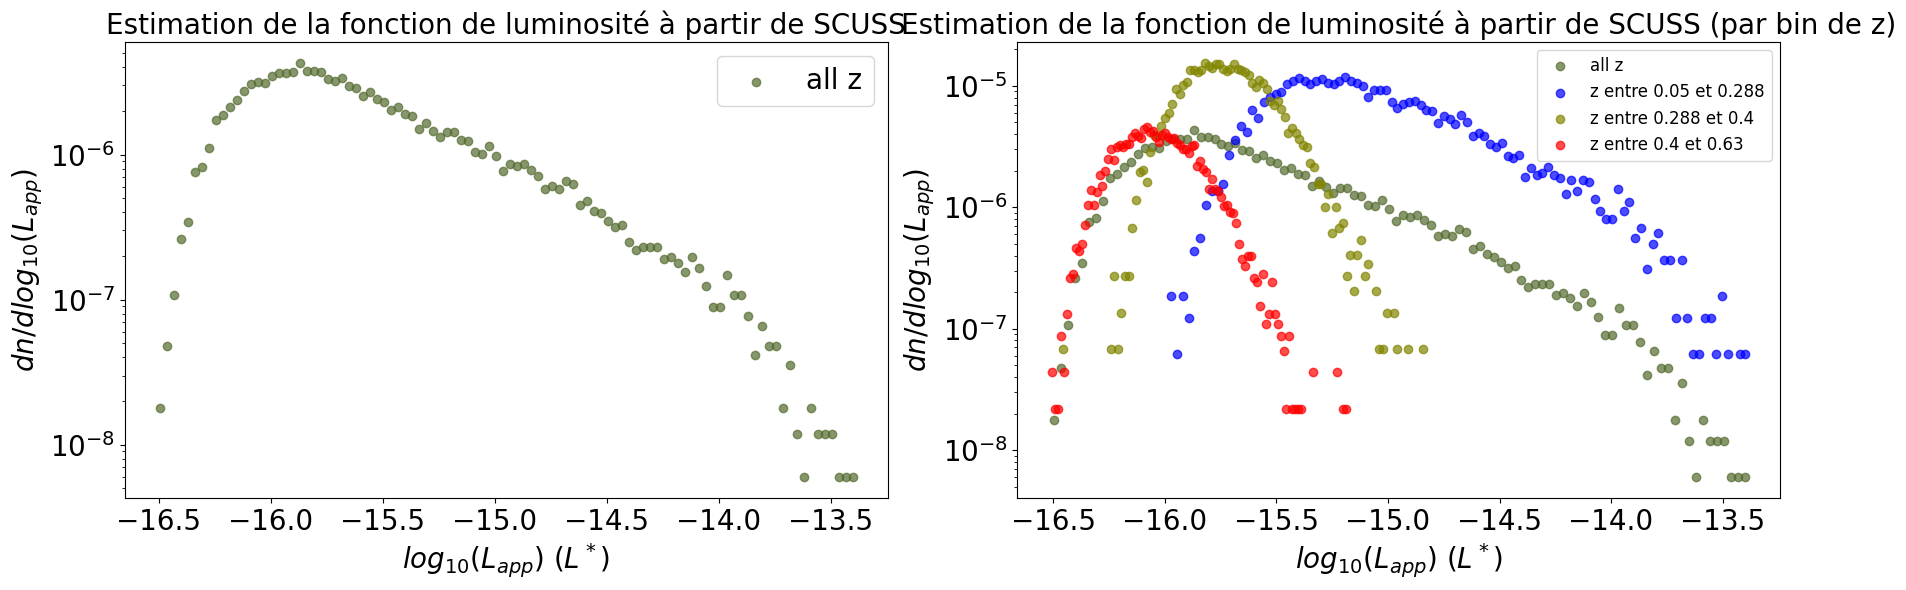

In [ ]:
'''# log10(Lapp)
plt.figure(figsize=(12, 6))
plt.hist(log10_Lapp_SCUSS, bins=100, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{app})$ ($L^*$)') 
plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title(r'Histogramme des luminosités apparentes "$log_{10}(L_{app})$" des amas dans SCUSS')'''
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: All z
ax = axes[0]
ax.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='darkolivegreen', alpha=0.7)
#ax.set_ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
ax.set_xlabel(r'$log_{10}(L_{app})$ ($L^*$)')
ax.set_ylabel(r'$dn / dlog_{10}(L_{app})$')
ax.set_yscale('log')
ax.set_title(r'Estimation de la fonction de luminosité à partir de SCUSS')
ax.legend(['all z'])

# Subplot 2: Par bin de z
ax2 = axes[1]
ax2.scatter(bin_centers_Lapp_log10, n_SCUSS_Lapp_log10, color='darkolivegreen', label='all z', alpha=0.7)
for i, subtable in enumerate(subtables_z_SCUSS):
    Lapp_subtable = subtable['Lapp']
    log10_Lapp_subtable = np.log10(Lapp_subtable)  
    volume_subtable = Volume_survey(angular_area_SCUSS_deg2, [bornes_z_SCUSS[i], bornes_z_SCUSS[i+1]])
    bin_centers_log10_Lapp_subtable, counts_log10_Lapp_subtable, bin_width_SCUSS_Lapp_log10, n_SCUSS_log10_Lapp_subtable = compute_histogram_density(
        log10_Lapp_subtable, bins=100, volume=volume_subtable
    )
    ax2.scatter(
        bin_centers_log10_Lapp_subtable,
        n_SCUSS_log10_Lapp_subtable,
        label=f'z entre {round(bornes_z_SCUSS[i],3)} et {round(bornes_z_SCUSS[i+1],3)}',
        color=cmap_blue2red(i / (len(subtables_z_SCUSS) - 1)),
        alpha=0.7,
    )
ax2.set_xlabel(r'$log_{10}(L_{app})$ ($L^*$)')
ax2.set_ylabel(r'$dn / dlog_{10}(L_{app})$')
ax2.set_yscale('log')
#ax2.set_ylim(0.5*1e-8,1e-5) # Bizarremment sans ça le plot n'affiche pas tout les points
ax2.set_title(r'Estimation de la fonction de luminosité à partir de SCUSS (par bin de z)')
ax2.legend(fontsize=12)

plt.tight_layout()

### Coupure L_app

#### Récupération / Calculs valeurs

In [71]:
# A partir de dn/dlog10(Lapp) ci-dessus, on en déduit une coupure minimale de détection de cette survey en Lapp
log10_Lapp_min = -14.5 ; L_app_min = 10**log10_Lapp_min # En unités de L*
log10_Lapp_min_2 = -16.5 ; L_app_min_2 = 10**log10_Lapp_min_2 # En unités de L*


# Maintenant in va calculer la coupure en redshift associé à celle en luminosité apparente pour chaque bin de log10(L1mpc)
arg_inv_lum_dist = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min)) # Homogène à une distance lumineuse en pc
arg_inv_lum_dist_2 = 10 * np.sqrt((10**bin_centers_L1Mpc_log10) / (L_app_min_2)) 
z_max = inverse_luminosity_distance(arg_inv_lum_dist) # coupure en redshift associée à la coupure en luminosité apparente
z_max_2 = inverse_luminosity_distance(arg_inv_lum_dist_2)

bornes_z_cut_SCUSS = [0.05, z_max] 
volume_SCUSS_cut = Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS)

bornes_z_cut_SCUSS_2 = [0.05, z_max_2] 
volume_SCUSS_cut_2 = Volume_survey_array(angular_area_SCUSS_deg2,bornes_z_cut_SCUSS_2)

# On recalcule la densité maintenant par bin de L1Mpc maintenant qu'on dispose du volume d'observation pour chaque bin
n_SCUSS_L1Mpc_log10_cut = []
for i in range(len(bin_centers_L1Mpc_log10)):
    current_n_SCUSS_L1Mpc_log10 = (counts_L1Mpc_log10[i]/bin_width_SCUSS_L1Mpc_log10)/volume_SCUSS_cut[i]
    n_SCUSS_L1Mpc_log10_cut.append(current_n_SCUSS_L1Mpc_log10)




#### Tracés

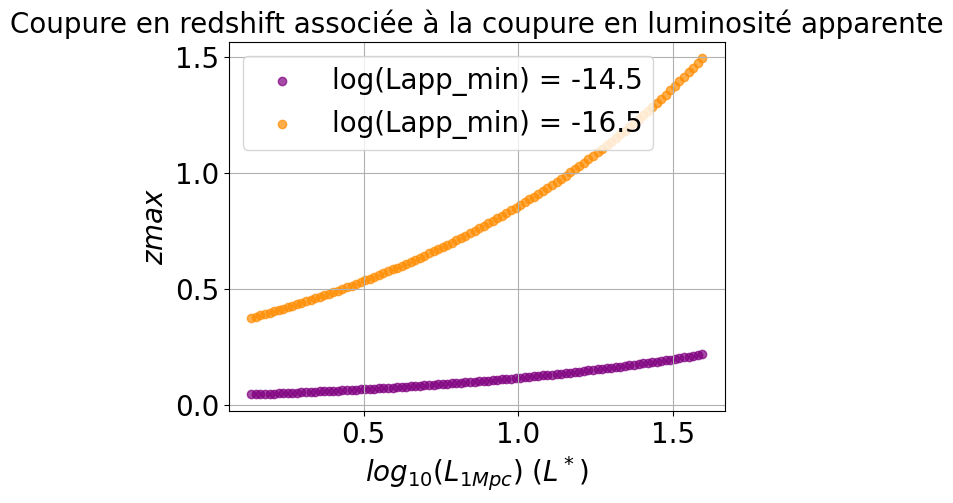

In [72]:
plt.scatter(bin_centers_L1Mpc_log10, z_max, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, z_max_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$z{max}$')
plt.title(f'Coupure en redshift associée à la coupure en luminosité apparente')
plt.grid(True)
plt.legend()


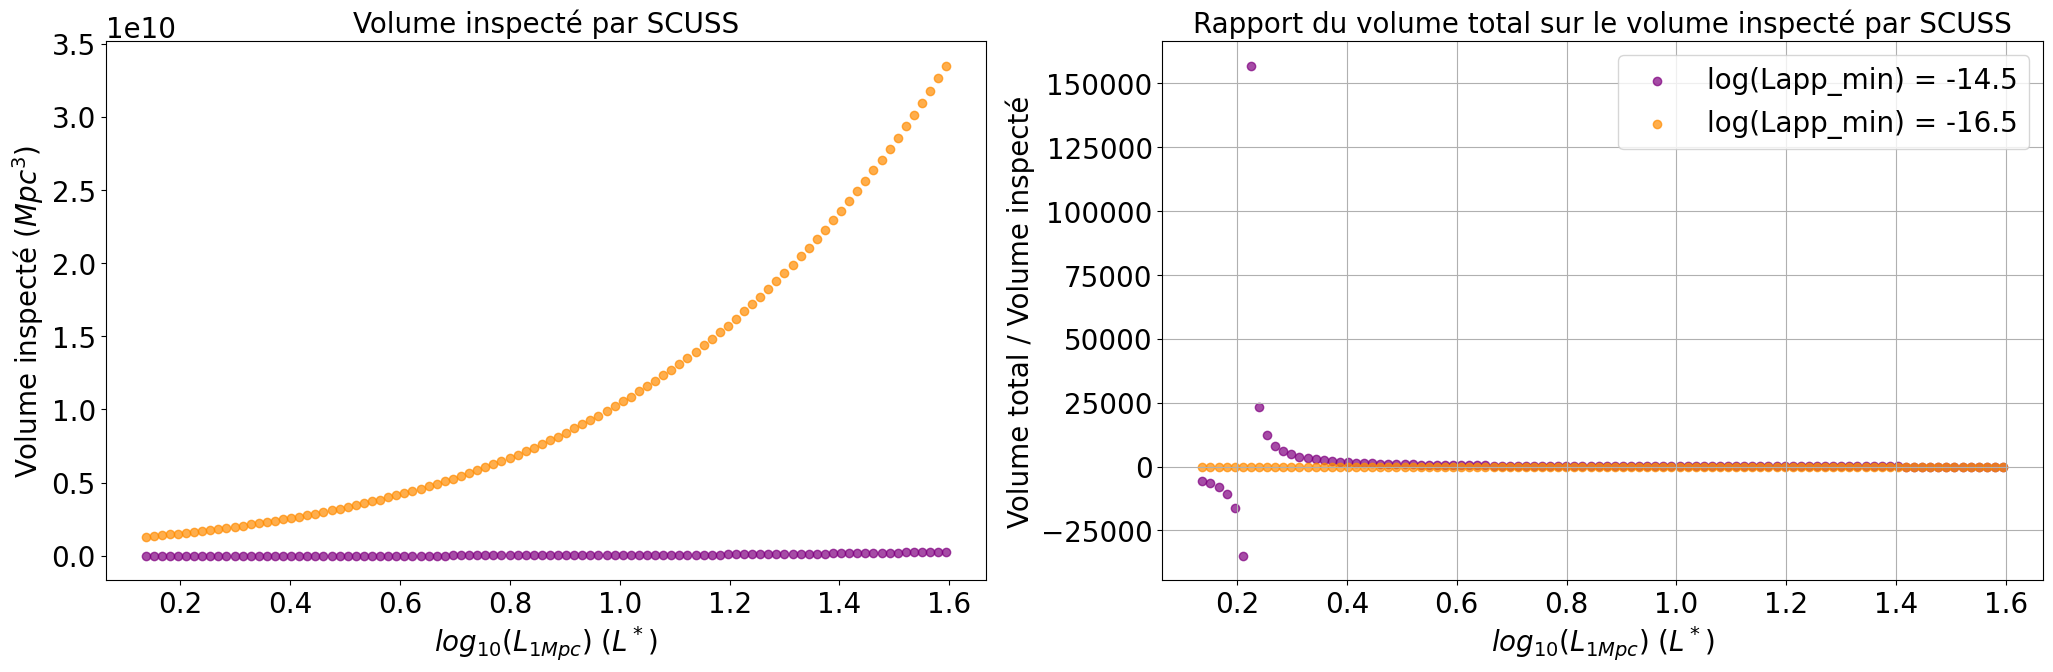

In [73]:
fig1 = plt.figure(figsize=(25, 7))

plt.subplot(121)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut, color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS_cut_2, color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'Volume inspecté $(Mpc^3)$')
plt.title(f'Volume inspecté par SCUSS')

plt.subplot(122)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut), color='purple',label=f'log(Lapp_min) = {log10_Lapp_min}',alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, volume_SCUSS/np.array(volume_SCUSS_cut_2), color='darkorange',label=f'log(Lapp_min) = {log10_Lapp_min_2}',alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'Volume total / Volume inspecté')
plt.title(f'Rapport du volume total sur le volume inspecté par SCUSS')

plt.grid(True)
plt.legend()


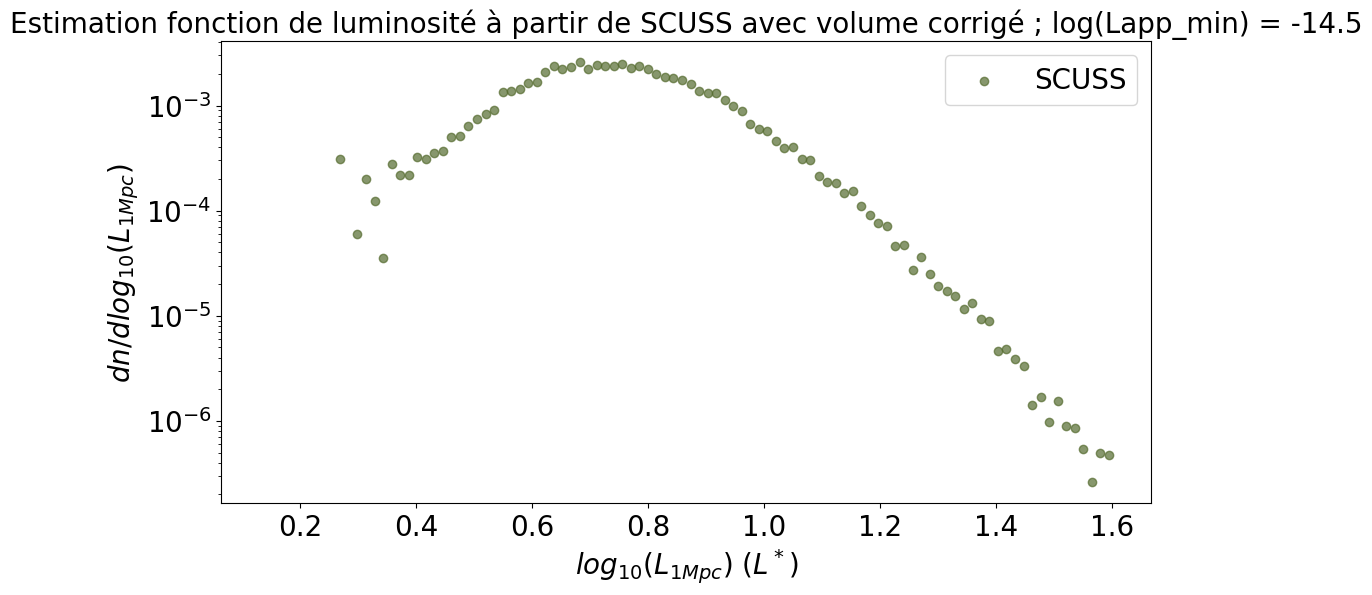

In [74]:
fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label='SCUSS', alpha=0.7) 
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

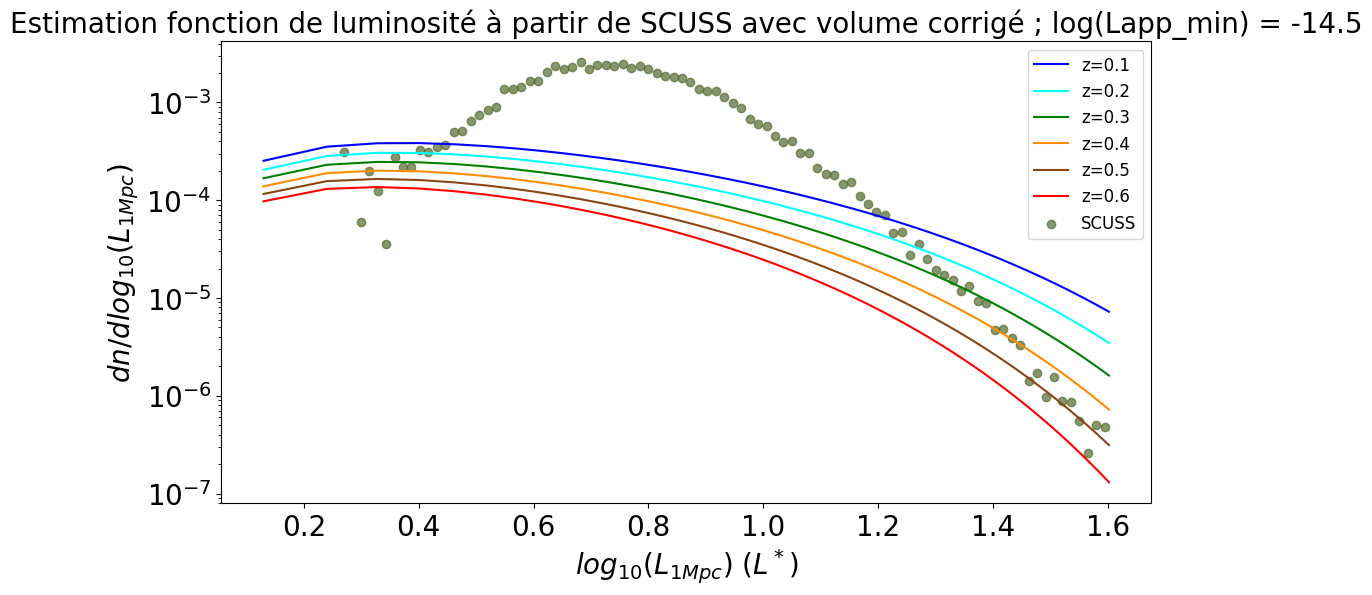

In [75]:
# Mpc ^-3 dex -1

fig1 = plt.figure(figsize=(12, 6))

#cmap = plt.get_cmap('tab10') # Matplotlib's collection of predefined colormaps
for i, z in enumerate(array_z): # On plot dn/dL1Mpc pour chaque redshift
    plt.plot(
        array_log10_L1Mpc_SCUSS,
        CLF_log10_MRP_GSR[i], # Pour le ième redshift de array_z
        label=f'z={z}',
        color=cmap_blue2red(i/(len(array_z) - 1)) # i / (len(array_z) - 1) → i normalisé entre 0 et 1 pour le colormap
    )

plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label='SCUSS', alpha=0.7)


plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend(fontsize=12)

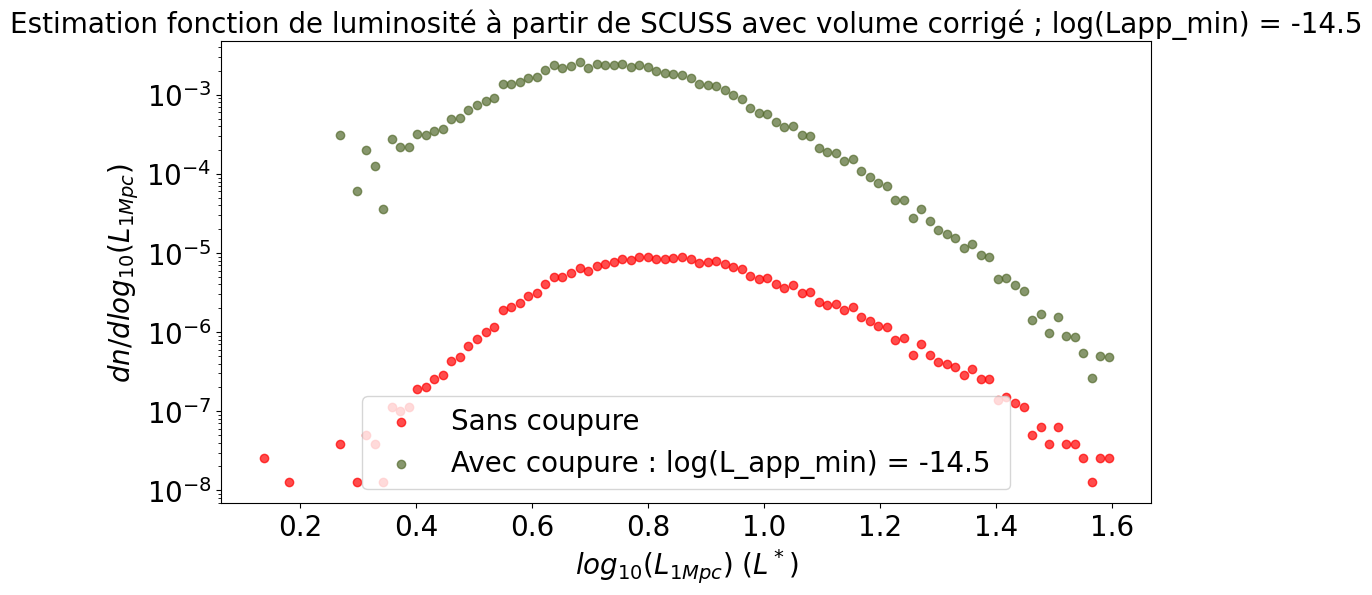

In [76]:
# Comparaison avec et sans coupure

fig = plt.figure(figsize=(12, 6))
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10, color='red', label='Sans coupure', alpha=0.7)
plt.scatter(bin_centers_L1Mpc_log10, n_SCUSS_L1Mpc_log10_cut, color='darkolivegreen', label=f'Avec coupure : log(L_app_min) = {round(log10_Lapp_min,3)} ', alpha=0.7)
plt.xlabel(r'$log_{10}(L_{1Mpc})$ ($L^*$)')
plt.ylabel(r'$dn / dlog_{10}(L_{1Mpc})$')
plt.yscale('log')
plt.title(f"Estimation fonction de luminosité à partir de SCUSS avec volume corrigé ; log(Lapp_min) = {log10_Lapp_min}")
plt.legend()

## eRASS1

### Calculs prélims

In [79]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen

table_eRASS1 = fits_to_dataframe(path_eRASS1)
volume_eRASS1 = Volume_survey(angular_area_eRASS1_deg2,bornes_z)

nb_bins_z = 3 ; nb_bornes_z = nb_bins_z + 1 

In [80]:
# On crée plusieurs subsamples de la table eRASS1 en fonction des bornes de z
# Largeur en z identiques - nombre d'éléments différents

bornes_z_eRASS1 = np.linspace(0,np.max(table_eRASS1['zBest']),nb_bornes_z) # On va faire plusieurs tracés en fonction de plusieurs redshifts (n bins de z issus des n+1 bornes de z)
subtables_z_eRASS1 = []
for i in range(len(bornes_z_eRASS1)-1):
    subtable = table_eRASS1[(table_eRASS1['zBest'] >= bornes_z_eRASS1[i]) & (table_eRASS1['zBest'] <= bornes_z_eRASS1[i+1])]
    print(f'bin {i} : z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}')
    subtables_z_eRASS1.append(subtable)

M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
M500_eRASS1 = M500_eRASS1[(M500_eRASS1 > 12.7) & (M500_eRASS1 < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)

M500_eRASS1_sub_z = []
for subtable in subtables_z_eRASS1:
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)
    M500_eRASS1_sub_z.append(M500_sub)
    nb_bins_z = 3 ; nb_bornes_z = nb_bins_z + 1 




# Largeur en z différentes - même nombre d'éléments
# Create quantile-based bins for 'zBest'
table_eRASS1['z_bin'], bornes_z_eRASS1_2 = pd.qcut(table_eRASS1['zBest'], q=nb_bins_z, retbins=True, labels=False)

# Create subtables for each bin
subtables_z_eRASS1_2 = []
for i in range(nb_bins_z):
    subtable = table_eRASS1[table_eRASS1['z_bin'] == i]
    print(f'bin {i}: z from {round(bornes_z_eRASS1_2[i],3)} to {round(bornes_z_eRASS1_2[i+1],3)}, count={len(subtable)}')
    subtables_z_eRASS1_2.append(subtable)

M500_eRASS1_sub_z_2 = []
for subtable in subtables_z_eRASS1_2:
    M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
    M500_sub = M500_sub[(M500_sub > 12.7) & (M500_sub < 15.5)] # On ne garde que les amas compris entre les bornes de masses utilisées pour le calcul de la CMF (pour DESI LEgacy, on conserve tout)
    M500_eRASS1_sub_z_2.append(M500_sub)

bin 0 : z allant de 0.0 à 0.441
bin 1 : z allant de 0.441 à 0.881
bin 2 : z allant de 0.881 à 1.322
bin 0: z from 0.003 to 0.212, count=4083
bin 1: z from 0.212 to 0.425, count=4081
bin 2: z from 0.425 to 1.322, count=4083


C:\Users\ED282972\AppData\Local\Temp\ipykernel_23040\3948876106.py:11: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_23040\3948876106.py:16: RuntimeWarning: divide by zero encountered in log10
  M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun
C:\Users\ED282972\AppData\Local\Temp\ipykernel_23040\3948876106.py:37: RuntimeWarning: divide by zero encountered in log10
  M500_sub = np.log10(np.array(subtable['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun


In [82]:
nb_bins_histos_ERASS1 = 40 #nb de bins de masse pour les prochains histogrammes

In [83]:
# Calcul estimation de la fonction de masse à partir de eRASS1 ; calculs des erreurs poissoniennes

bin_centers, counts_eRASS1, bin_width_eRASS1, n_eRASS1 = compute_histogram_density(M500_eRASS1,
                                                                                    bins=nb_bins_histos_ERASS1,
                                                                                    range=[12.5, 15.5],
                                                                                    volume=volume_eRASS1)

#Estimation des erreurs poissoniennes
total = np.sum(counts_eRASS1)
errors_poisson_eRASS1 = np.sqrt(counts_eRASS1)
norm_counts_eRASS1 = counts_eRASS1 / (total * bin_width_eRASS1) ; errors_poisson_eRASS1_normalized = np.sqrt(counts_eRASS1) / (total * bin_width_eRASS1)

In [84]:
# Process histograms for each redshift bin
results = process_subtables_histogram(
    subtables=M500_eRASS1_sub_z,  # List of mass arrays for each z bin
    column=None,  # Not needed since we're passing arrays directly
    bins=nb_bins_histos_ERASS1,
    range=(12.5, 15.5),
    volume=volume_eRASS1,
    label_prefix='z=',
    color_map=lambda x: cmap_blue2red(x)
)

# Extract results into separate lists for compatibility with existing code
bin_centers_eRASS1_sub_z = [r['bin_centers'] for r in results]
counts_eRASS1_sub_z = [r['counts'] for r in results]
norm_counts_eRASS1_sub_z = [r['norm_counts'] for r in results]
n_eRASS1_sub_z = [r['density'] for r in results]
errors_poisson_eRASS1_sub_z = [r['errors'] for r in results]
errors_poisson_eRASS1_normalized_sub_z = [r['norm_errors'] for r in results]

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !



In [86]:
# Largeur en z différentes - même nombre d'éléments


# Utilisation de process_subtables_histogram pour calculer les mêmes quantités d'intérêt que précédemment

results_2 = process_subtables_histogram(
    subtables=M500_eRASS1_sub_z_2,  # List of mass arrays for each z bin (largeur en z différentes)
    column=None,  # Not needed since we're passing arrays directly
    bins=nb_bins_histos_ERASS1,
    range=(12.5, 15.5),
    volume=volume_eRASS1,
    label_prefix='z=',
    color_map=lambda x: cmap_blue2red(x)
)

# Extraction des résultats dans des listes séparées pour compatibilité avec le code existant
bin_centers_eRASS1_sub_z_2 = [r['bin_centers'] for r in results_2]
counts_eRASS1_sub_z_2 = [r['counts'] for r in results_2]
norm_counts_eRASS1_sub_z_2 = [r['norm_counts'] for r in results_2]
n_eRASS1_sub_z_2 = [r['density'] for r in results_2]
errors_poisson_eRASS1_sub_z_2 = [r['errors'] for r in results_2]
errors_poisson_eRASS1_normalized_sub_z_2 = [r['norm_errors'] for r in results_2]

# ATTENTION : On diminue fortement le nombre d'amas dans les bins de z plus grand, donc les stats sont moins fiables !

### Affichage histos masse (potentiellement à raccourcir)

In [87]:
nb_bins_histo = 40

Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.18  et l'écart type de  0.391  pour eRASS1 pour des z allant de 0.0 à 0.441
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.215  pour eRASS1 pour des z allant de 0.441 à 0.881
Moyenne de la masse des amas est de  14.403  et l'écart type de  0.159  pour eRASS1 pour des z allant de 0.881 à 1.322


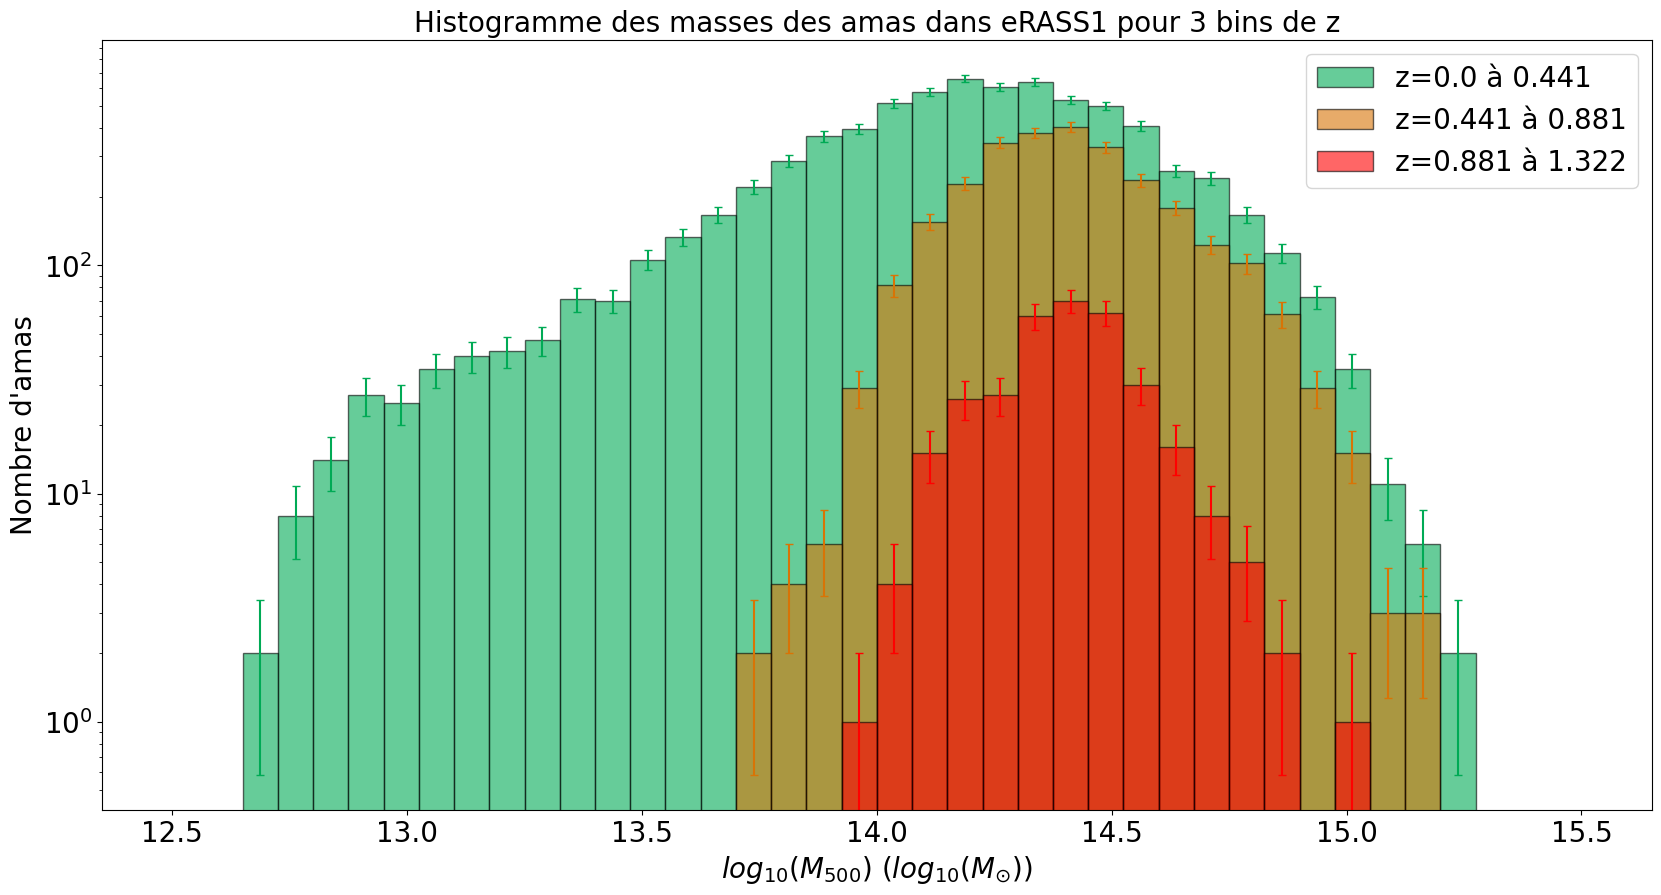

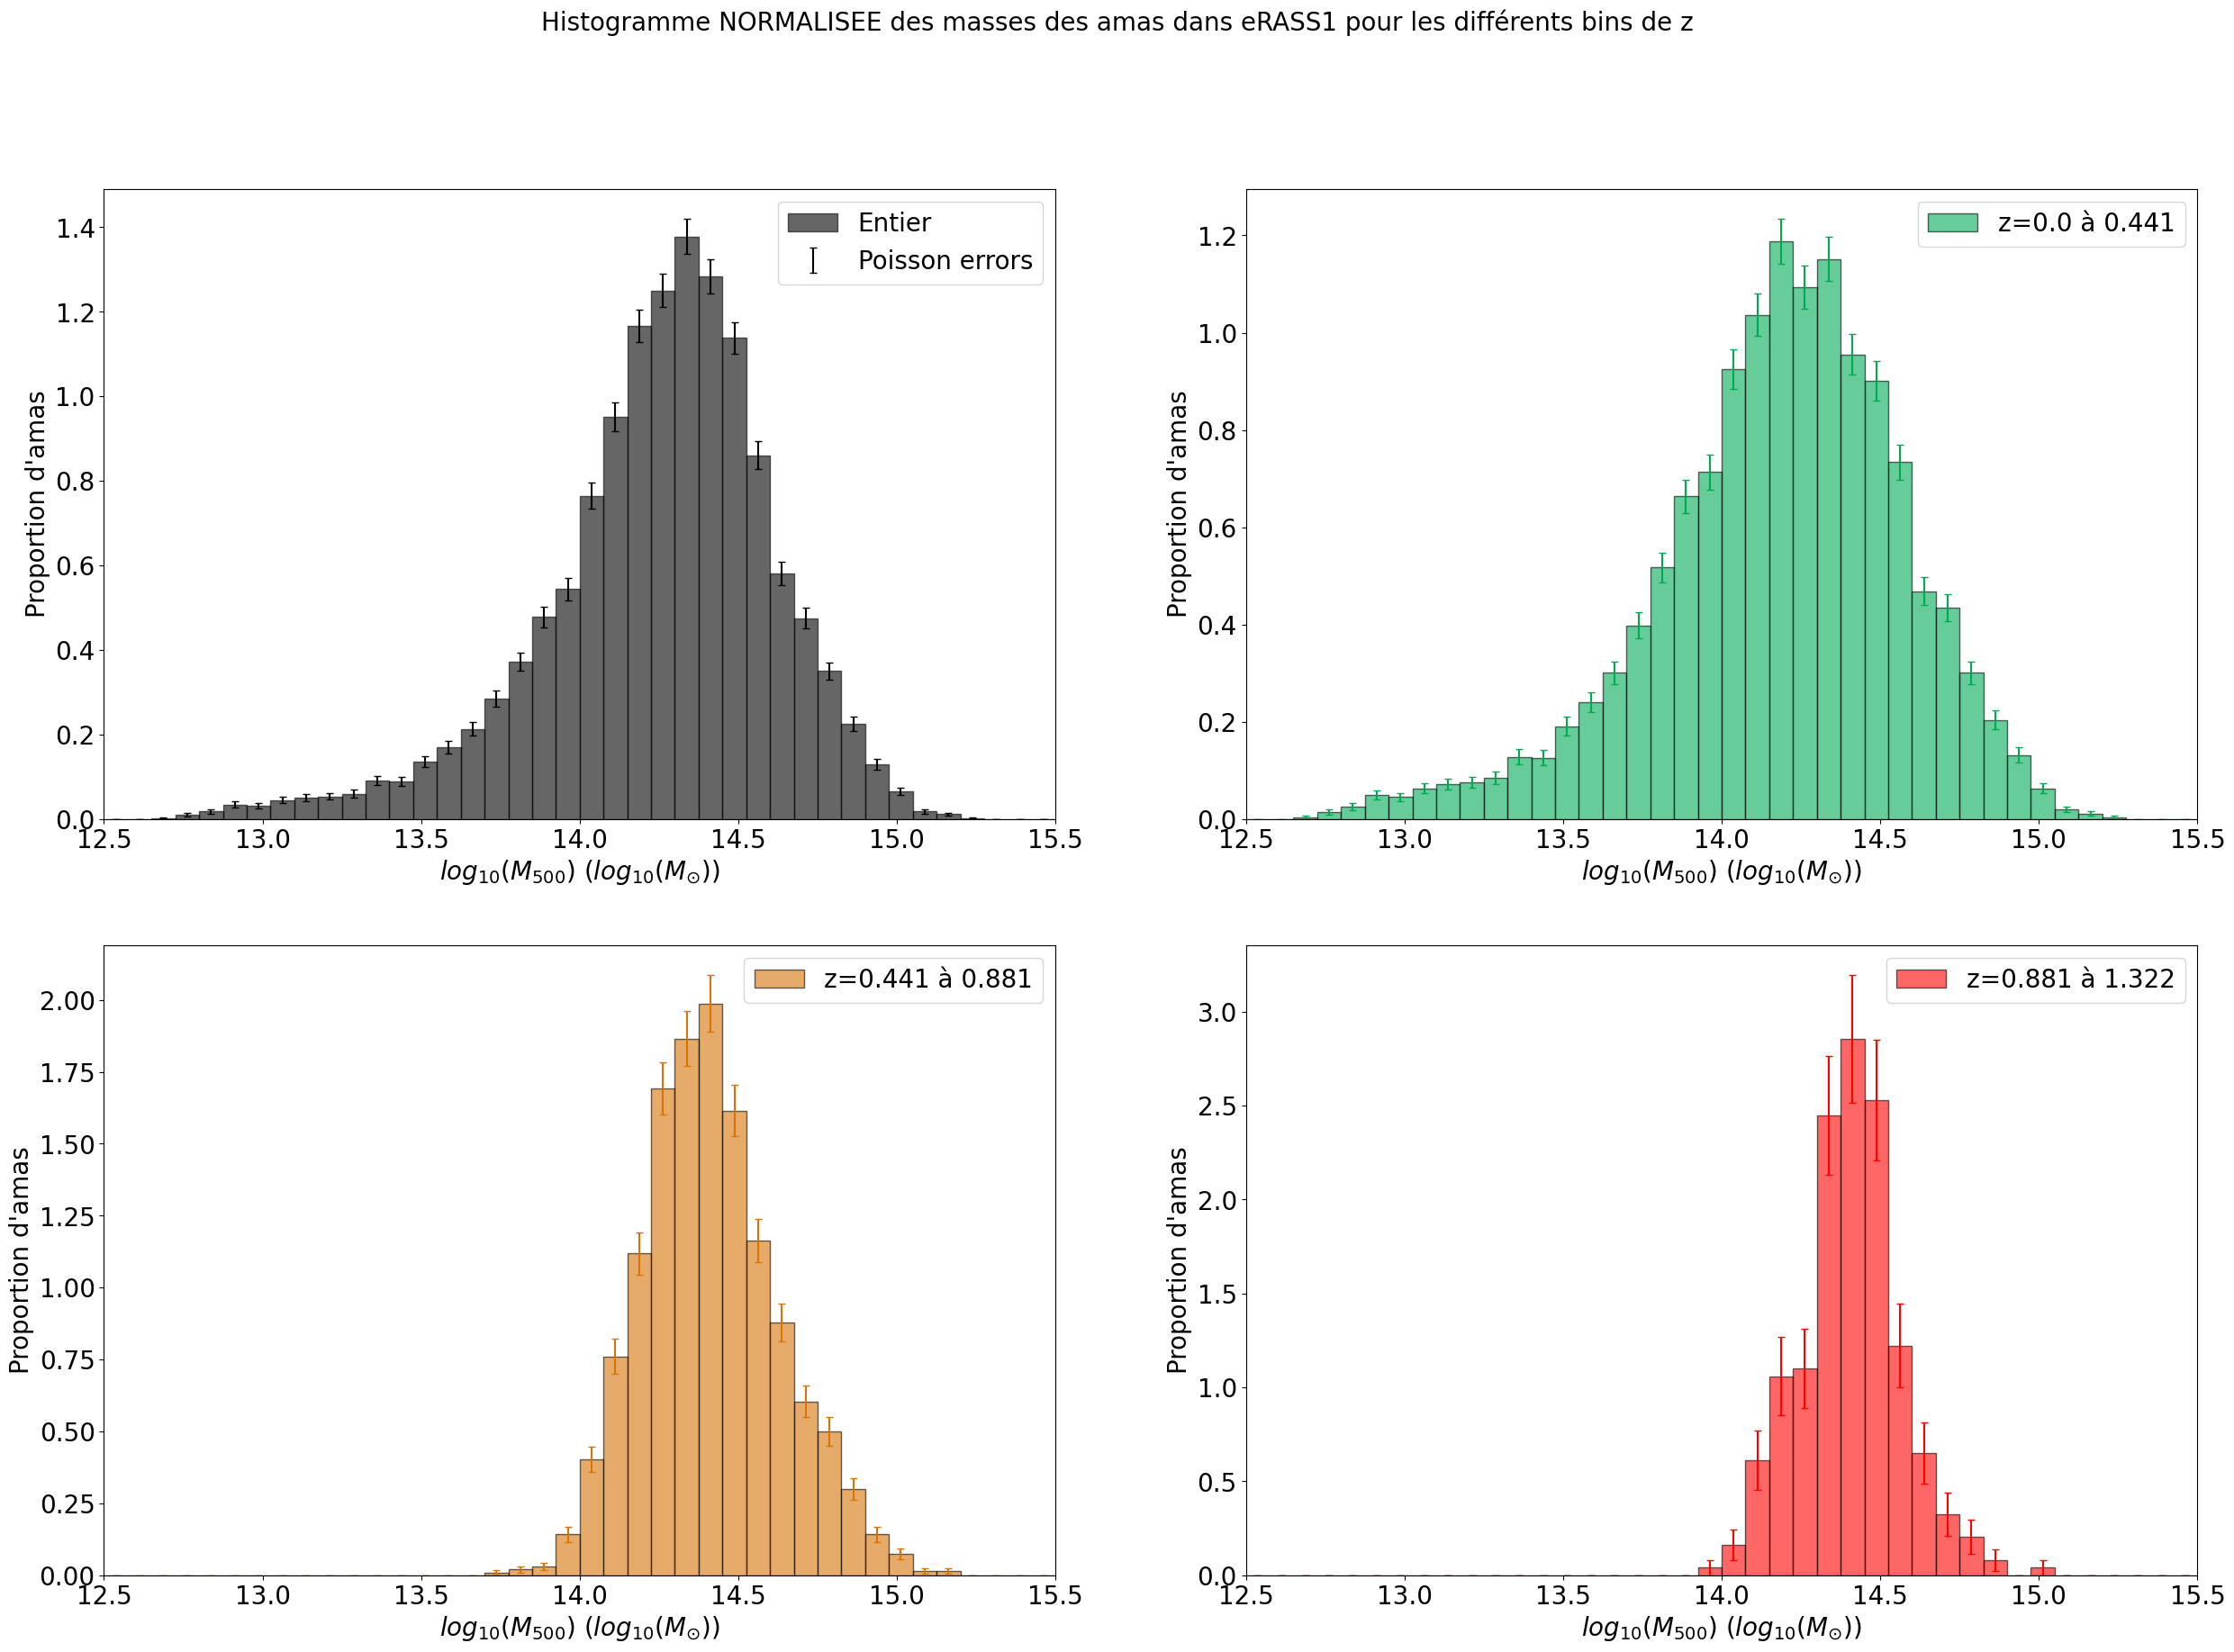

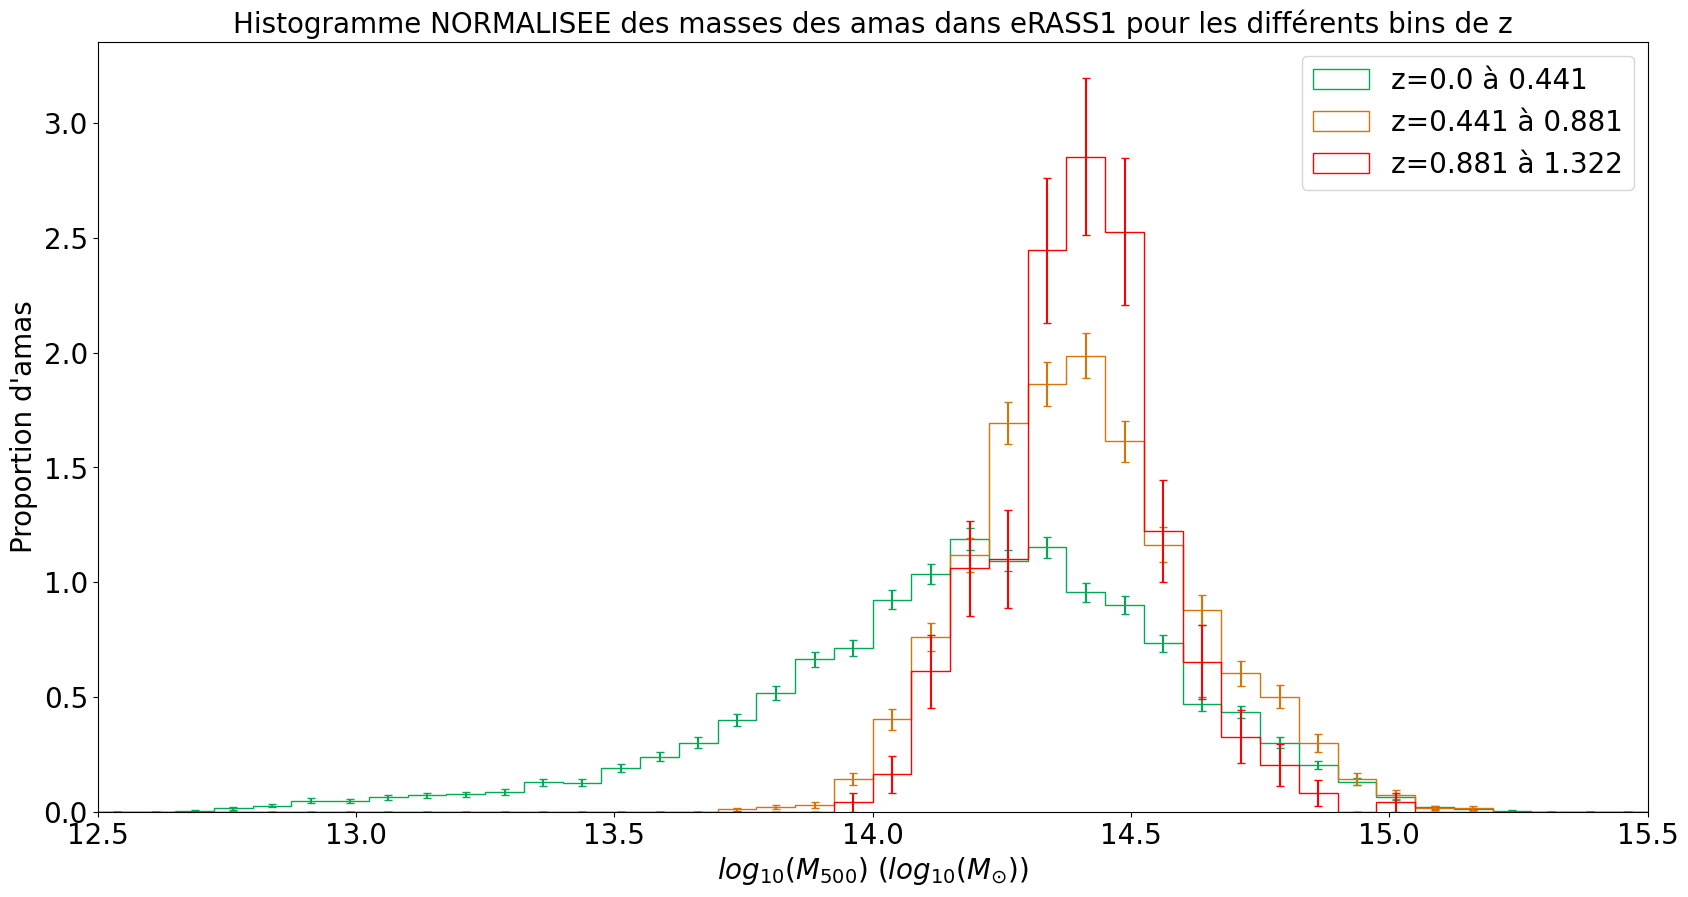

In [88]:
# Histo largeurs fixés - nb différents
# Note : Transformer tout ce code sous la forme de fonction pour éviter la répétition

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

#cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}")

    
    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=(12.5, 15.5),  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_sub_z[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()


# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=(12.5, 15.5), alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d’éléments dans le bin) ÷ (nombre total d’éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=(12.5, 15.5), 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),range=(12.5, 15.5), label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z[i], yerr=errors_poisson_eRASS1_normalized_sub_z[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()


Moyenne de la masse des amas est de  14.248  et l'écart type de  0.364  pour eRASS1
Moyenne de la masse des amas est de  14.019  et l'écart type de  0.424  pour eRASS1 pour des z allant de 0.003 à 0.212
Moyenne de la masse des amas est de  14.327  et l'écart type de  0.285  pour eRASS1 pour des z allant de 0.212 à 0.425
Moyenne de la masse des amas est de  14.413  et l'écart type de  0.213  pour eRASS1 pour des z allant de 0.425 à 1.322


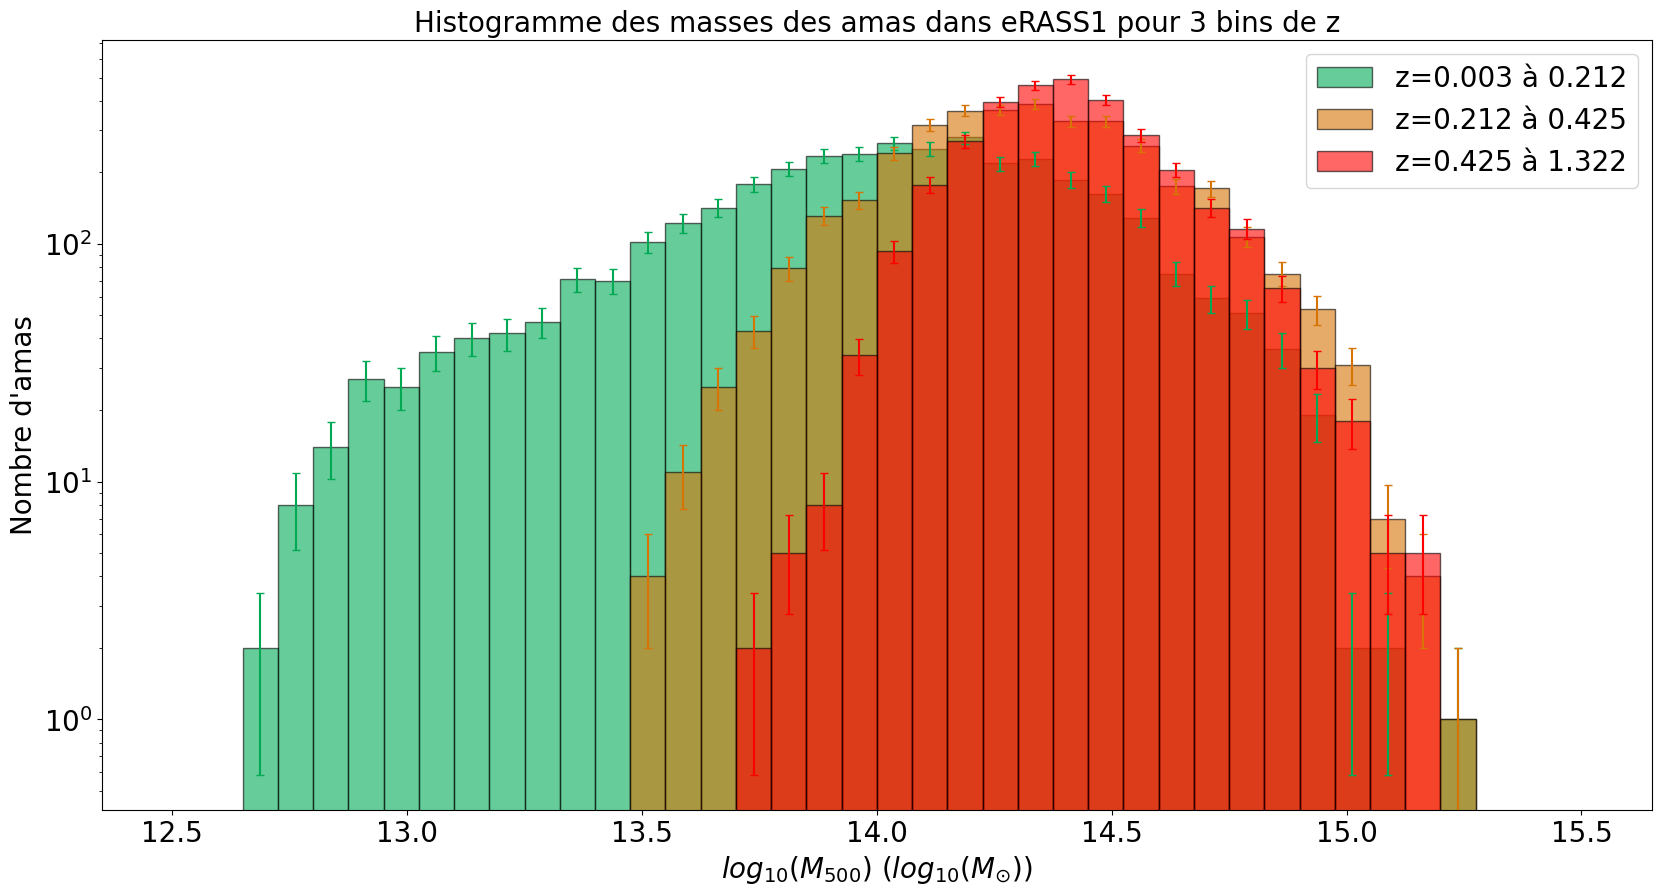

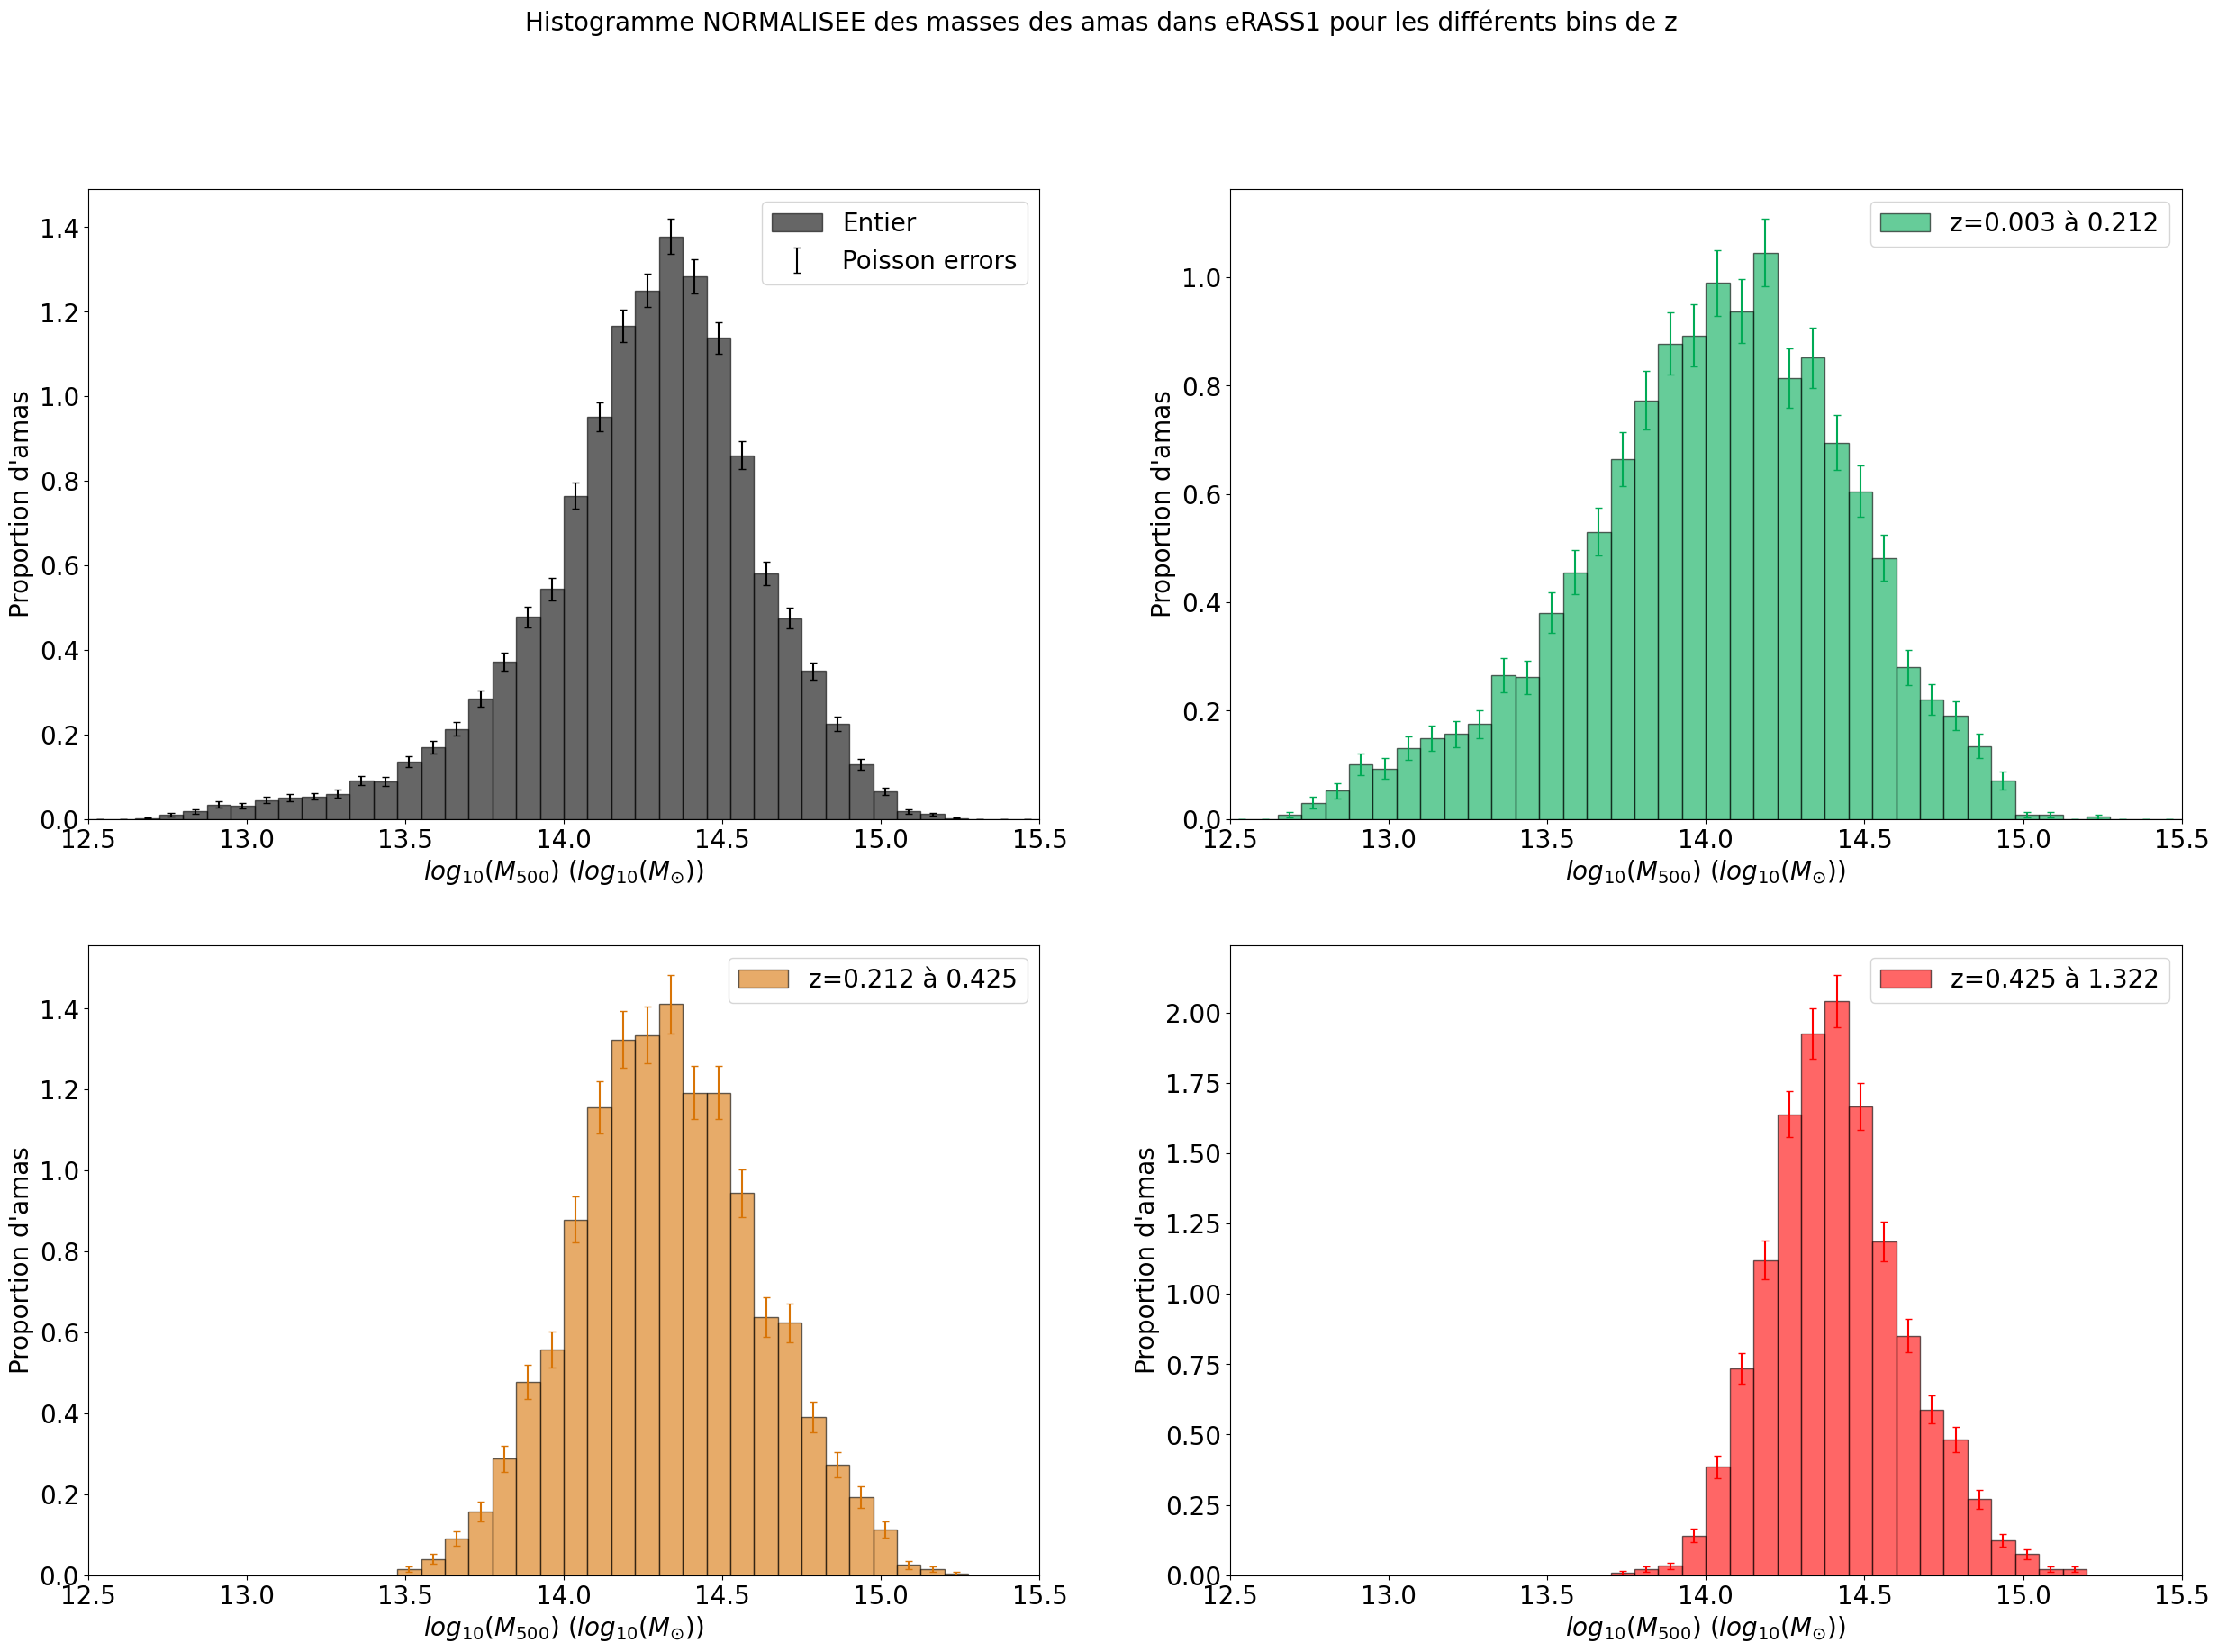

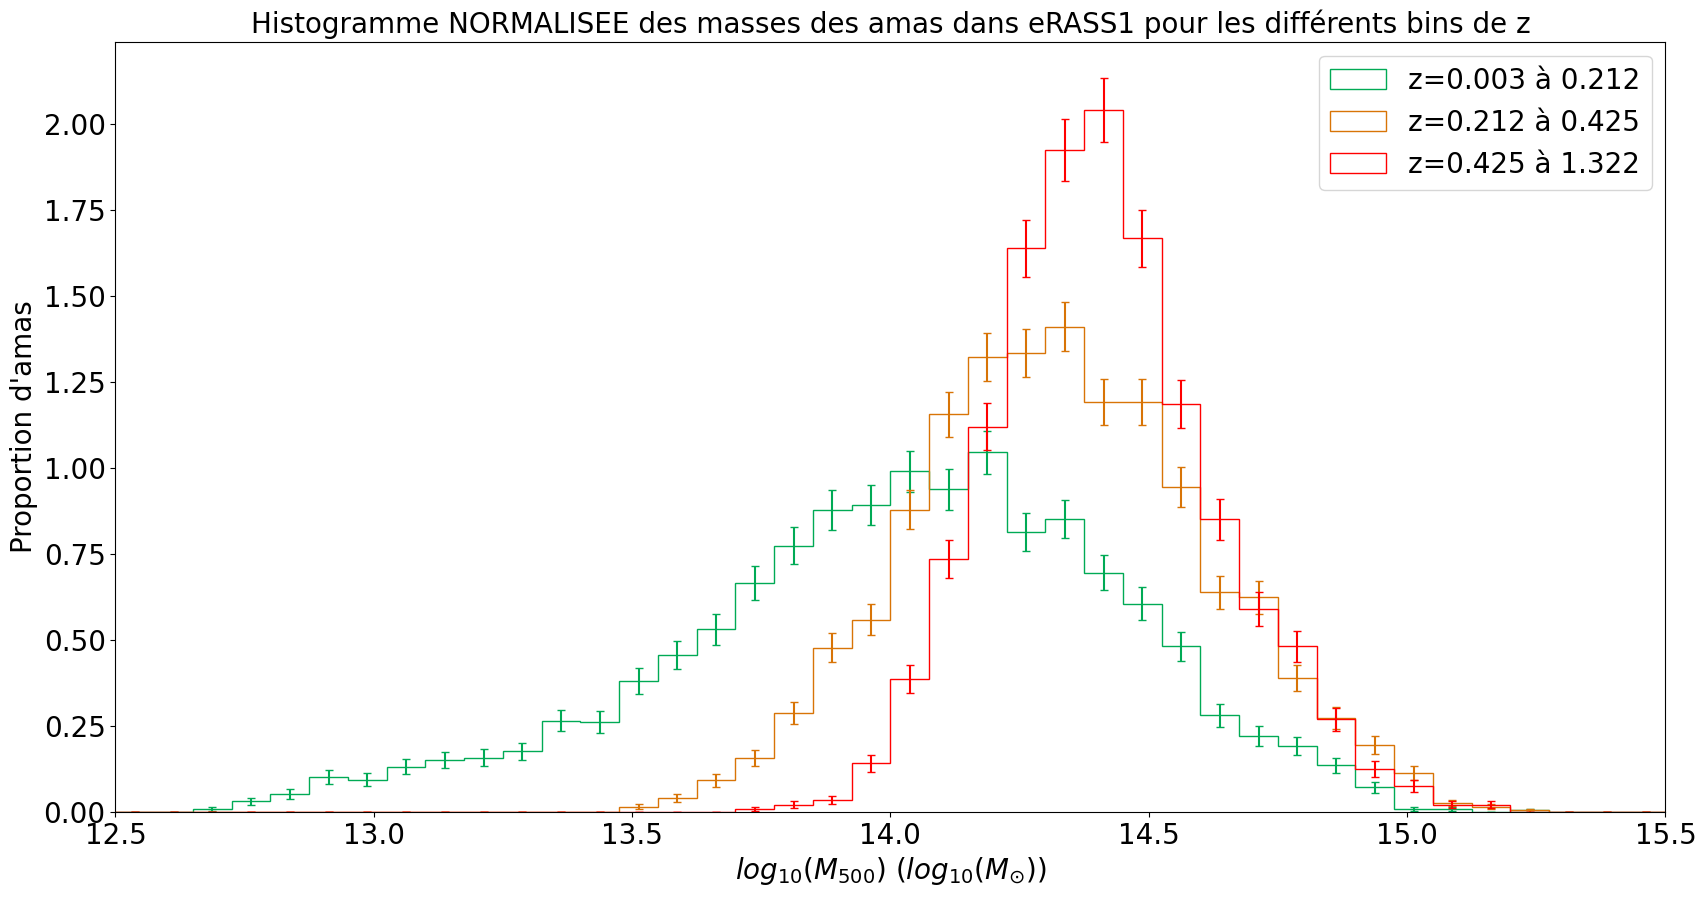

In [89]:
# Histo largeurs différentes - nb ~ fixées

# Histogramme des masses des amas dans eRASS1 sans normalisation
plt.figure(figsize=(20, 10))

plt.ylabel('Nombre d\'amas')
plt.yscale('log')
plt.title('Histogramme des masses des amas dans eRASS1')
print('Moyenne de la masse des amas est de ',round(np.mean(M500_eRASS1),3)," et l'écart type de ", round(np.std(M500_eRASS1),3), " pour eRASS1")

cmap = plt.get_cmap('tab10') 
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    print('Moyenne de la masse des amas est de ',round(np.mean(sub_mass),3),r" et l'écart type de ", round(np.std(sub_mass),3), f" pour eRASS1 pour des z allant de {round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}")

    plt.hist(
        sub_mass,
        bins=nb_bins_histo,
        range=(12.5, 15.5),  # On fixe la plage de l'histogramme pour qu'il soit comparable avec les autres !
        color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))),  # Normalisation de i pour le colormap
        alpha=0.6,
        edgecolor='black',
        label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}'
    )
    plt.errorbar(bin_centers, counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_sub_z_2[i], fmt='none', ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z))), capsize=3)    
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)') 
    plt.ylabel('Nombre d\'amas')
    plt.yscale('log')
    plt.title(f'Histogramme des masses des amas dans eRASS1 pour {nb_bins_z} bins de z')

plt.legend()




# Histogramme des masses des amas dans eRASS1 normalisé (chaqye nombre d'amas par bin est divisé par le nombre total d'amas dans eRASS1)
plt.figure(figsize=(30, 20))
plt.suptitle(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2 ,1)
plt.hist(M500_eRASS1, bins=nb_bins_histo, color='black',range=(12.5, 15.5), alpha = 0.6, edgecolor='black',label = 'Entier', density=True) #l'opition density=True normalise l'histogramme ((nombre d’éléments dans le bin) ÷ (nombre total d’éléments × largeur du bin))
plt.errorbar(bin_centers, norm_counts_eRASS1, yerr=errors_poisson_eRASS1_normalized, fmt='none', ecolor='black', capsize=3, label='Poisson errors')
plt.xlim(12.5, 15.5)
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
if nb_bins_histo == 100:
    plt.ylabel('Proportion d\'amas en %')
else:
    plt.ylabel('Proportion d\'amas')
plt.legend()

for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.subplot((nb_bins_z+1)//2 , (nb_bins_z+1)//2  ,i+2)
    plt.hist(sub_mass, bins=nb_bins_histo, range=(12.5, 15.5), 
             color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), edgecolor='black', alpha=0.6,
             label = f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True) #idem
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')
    plt.legend()

#M500_eRASS1_sub_z_2_partial = [M500_eRASS1_sub_z_2[0],M500_eRASS1_sub_z_2[2]]
plt.figure(figsize=(20, 10))
plt.title(f'Histogramme NORMALISEE des masses des amas dans eRASS1 pour les différents bins de z', fontsize=20)
for i,sub_mass in enumerate(M500_eRASS1_sub_z_2) :
    plt.hist(sub_mass, bins=nb_bins_histo, color=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))),range=(12.5, 15.5), label=f'z={round(bornes_z_eRASS1_2[i],3)} à {round(bornes_z_eRASS1_2[i+1],3)}', density=True, histtype='step') # Only edges
    plt.errorbar(bin_centers, norm_counts_eRASS1_sub_z_2[i], yerr=errors_poisson_eRASS1_normalized_sub_z_2[i], fmt='none',
                 ecolor=cmap_blue2red((i+1)/(len(M500_eRASS1_sub_z_2))), capsize=3)
    plt.xlim(12.5, 15.5)
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    if nb_bins_histo == 100:
        plt.ylabel('Proportion d\'amas en %')
    else:
        plt.ylabel('Proportion d\'amas')    
    plt.legend()


### Estimation CMF

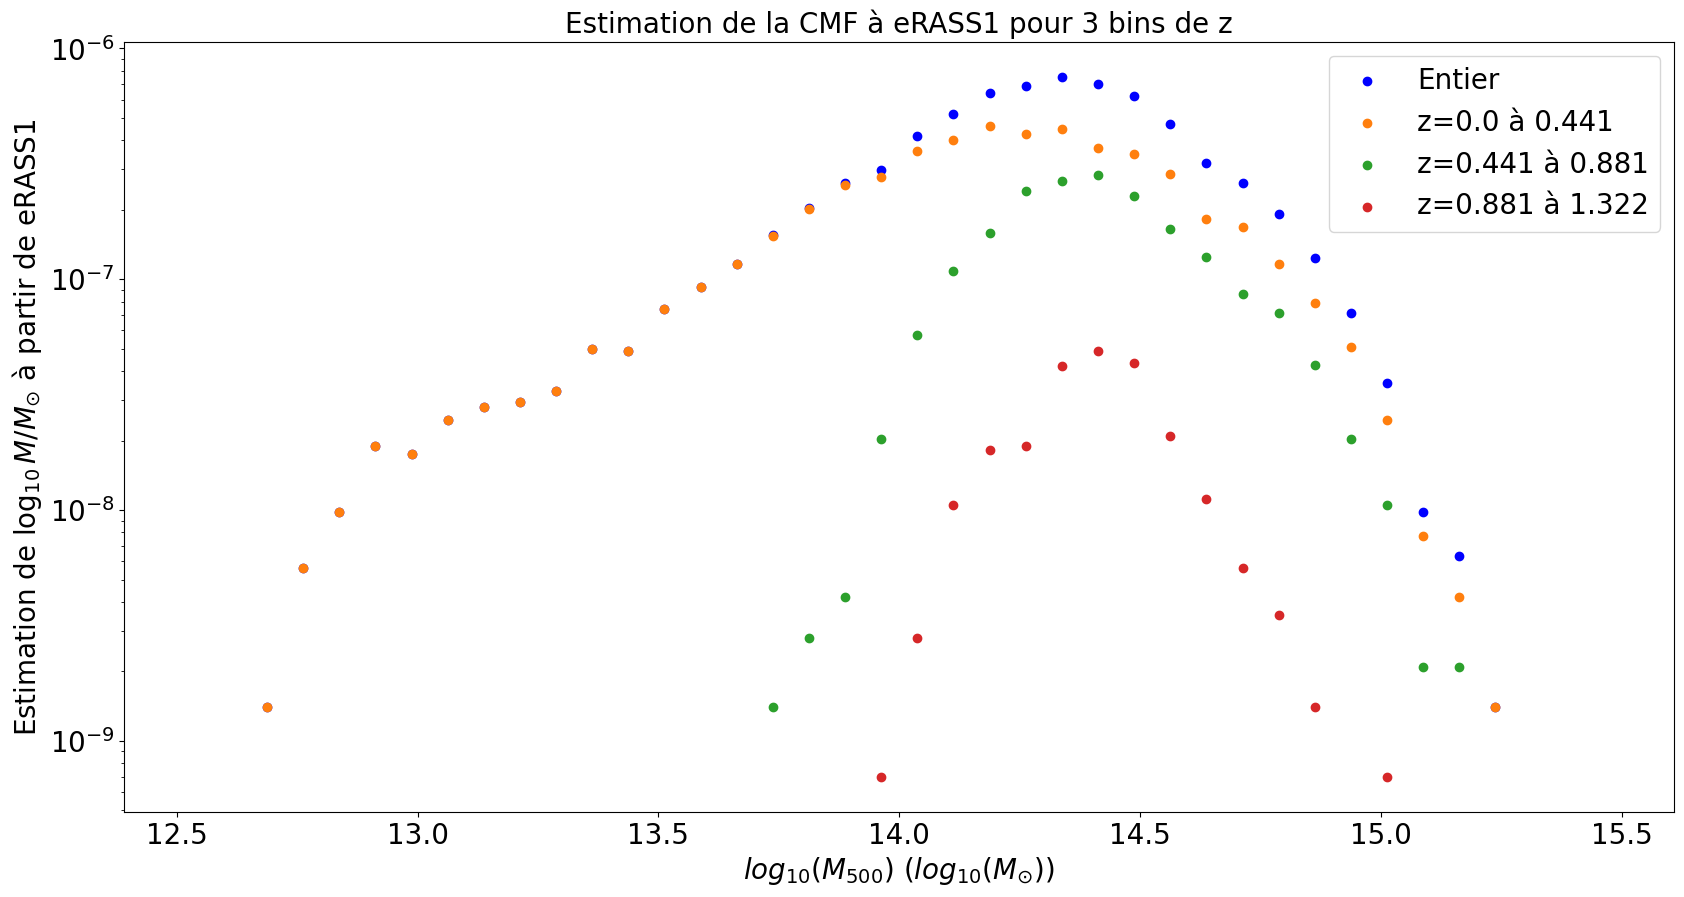

In [90]:
fig = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, n_eRASS1, color='blue', label='Entier') 
plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de eRASS1')
plt.yscale('log')
plt.title('Estimation de la CMF à eRASS1')
plt.legend()

cmap = plt.get_cmap('tab10') 
for i,sub_nrass in enumerate(n_eRASS1_sub_z) :
    plt.scatter(bin_centers_eRASS1_sub_z[i], sub_nrass, color=cmap(i+1), label=f'z={round(bornes_z_eRASS1[i],3)} à {round(bornes_z_eRASS1[i+1],3)}') 
    plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
    plt.ylabel(r'Estimation de $\log_{10} M / M_{\odot}$ à partir de eRASS1')
    plt.yscale('log')
    plt.title(f'Estimation de la CMF à eRASS1 pour {nb_bins_z} bins de z')
    plt.legend()


<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_23040\4093152440.py:22: SyntaxWarning: invalid escape sequence '\o'
  '''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)


'plt.legend()'

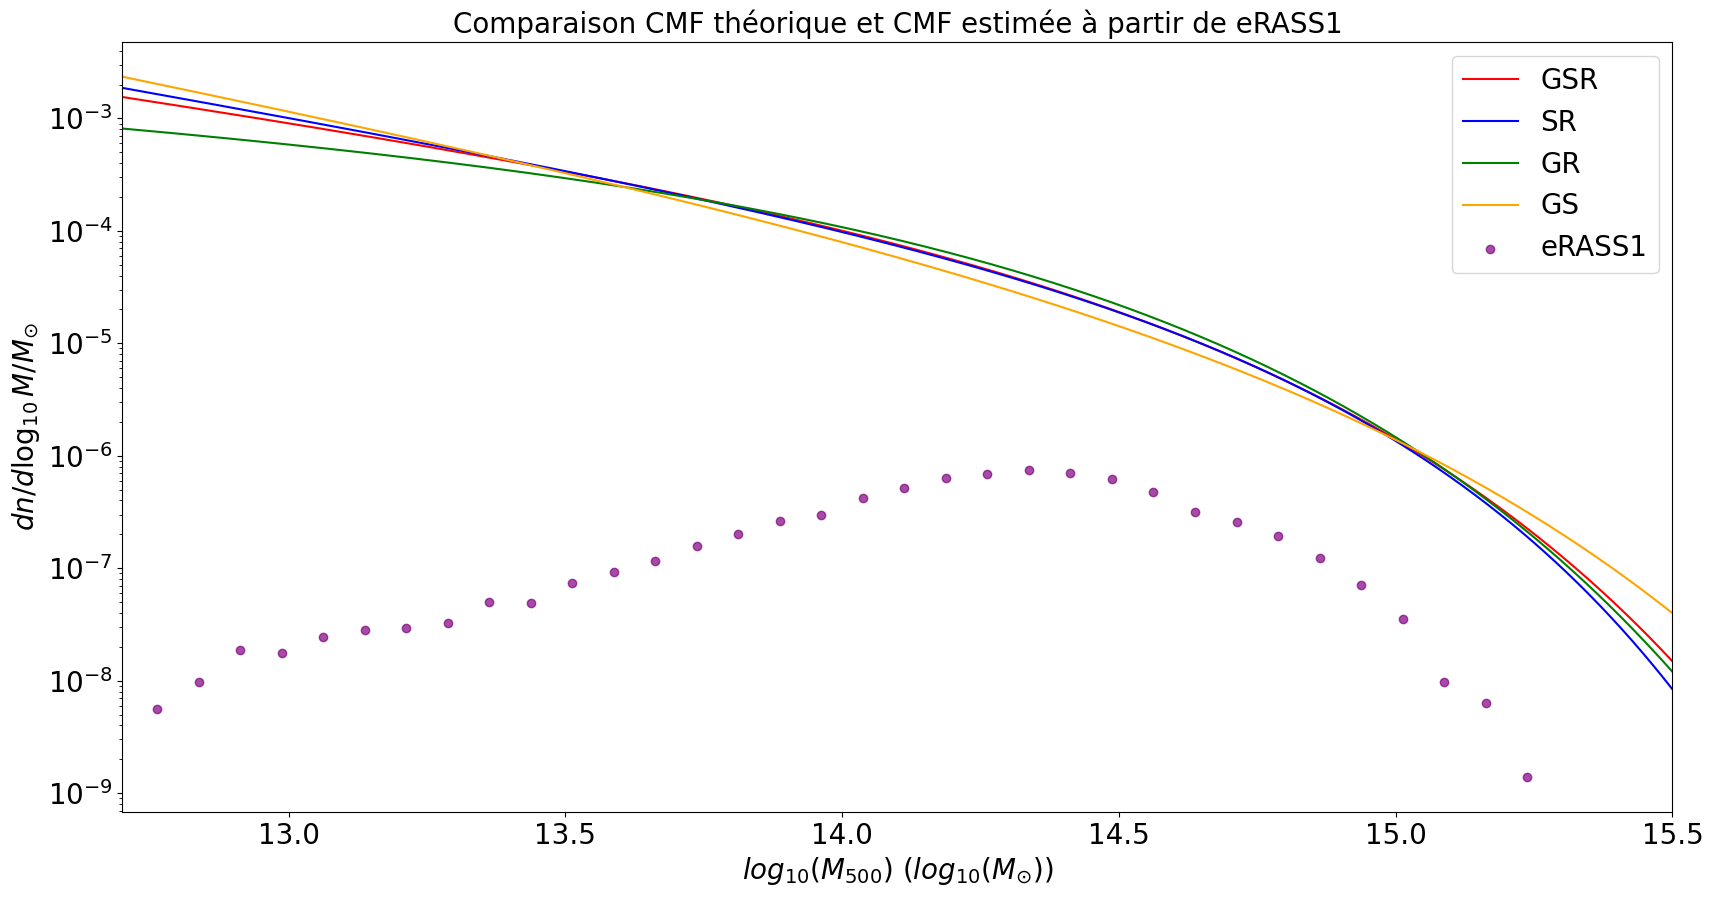

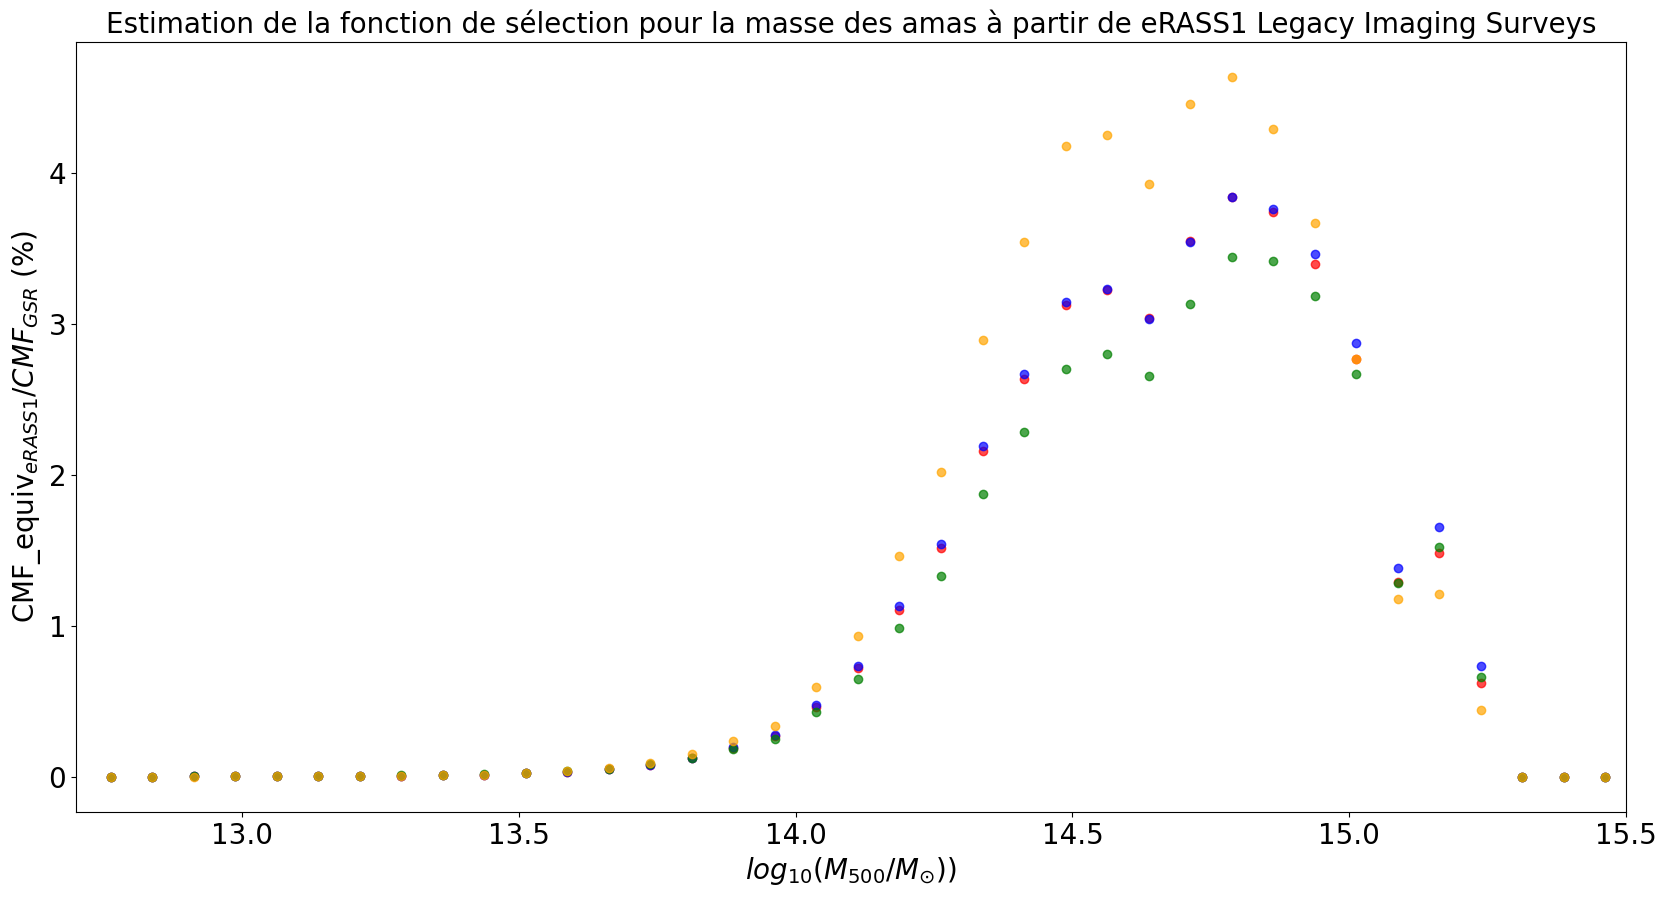

In [91]:
# Mpc ^-3 dex -1

# ATTENTION : On n'a pas pris en compte l'évolution en fonction du redshift, ni la masse de référence utilisée pour la fonction MRP (M500 ou autre chose ? → je n'arrive pas à trouver dans les papiers pour l'instant)

fig1 = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)
plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')

plt.legend()

'''residuals_GSR = np.abs(CMF_GSR_func(bin_centers) - n_eRASS1)
residuals_SR = np.abs(CMF_SR_func(bin_centers) - n_eRASS1)
residuals_GR = np.abs(CMF_GR_func(bin_centers) - n_eRASS1)
residuals_GS = np.abs(CMF_GS_func(bin_centers) - n_eRASS1)


fig2 = plt.figure(figsize=(20, 10))
plt.scatter(bin_centers, residuals_GSR, color='red', label='GSR Residuals', alpha=0.7)-
plt.scatter(bin_centers, residuals_SR, color='blue', label='SR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GR, color='green', label='GR Residuals', alpha=0.7)
plt.scatter(bin_centers, residuals_GS, color='orange', label='GS Residuals', alpha=0.7)
plt.xlim(12.2, 15.7)
plt.yscale('log')

plt.xlabel(r'$log_{10}(M_{500})$ ($log_{10}(M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')


plt.title('Résidus entre la CMF théorique et la CMF estimée à partir de eRASS1')
'''

# On essaie d'en déduire une fonction de sélection en fonction de la masse des amas

estimation_selection_function_masse_GSR = n_eRASS1/CMF_GSR_func(bin_centers)
estimation_selection_function_masse_SR = n_eRASS1/CMF_SR_func(bin_centers)
estimation_selection_function_masse_GR = n_eRASS1/CMF_GR_func(bin_centers)
estimation_selection_function_masse_GS = n_eRASS1/CMF_GS_func(bin_centers)



plt.figure(figsize=(20, 10))

plt.scatter(bin_centers, estimation_selection_function_masse_GSR * 100, color='red', alpha=0.7,label='GSR')
plt.scatter(bin_centers, estimation_selection_function_masse_SR * 100, color='blue', alpha=0.7,label='SR')
plt.scatter(bin_centers, estimation_selection_function_masse_GR * 100, color='green', alpha=0.7,label='GR')
plt.scatter(bin_centers, estimation_selection_function_masse_GS * 100, color='orange', alpha=0.7,label='GS')

'''plt.hlines(100, 12.7, 15.5, color='black', linestyle='dashed', label='100%')
plt.hlines(0, 12.7, 15.5, color='black', linestyle='dashed', label='0%')'''

plt.xlim(12.7, 15.5)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'CMF_equiv$_{eRASS1} / CMF_{GSR}$ (%)')
plt.title('Estimation de la fonction de sélection pour la masse des amas à partir de eRASS1 Legacy Imaging Surveys')

'''plt.legend()'''

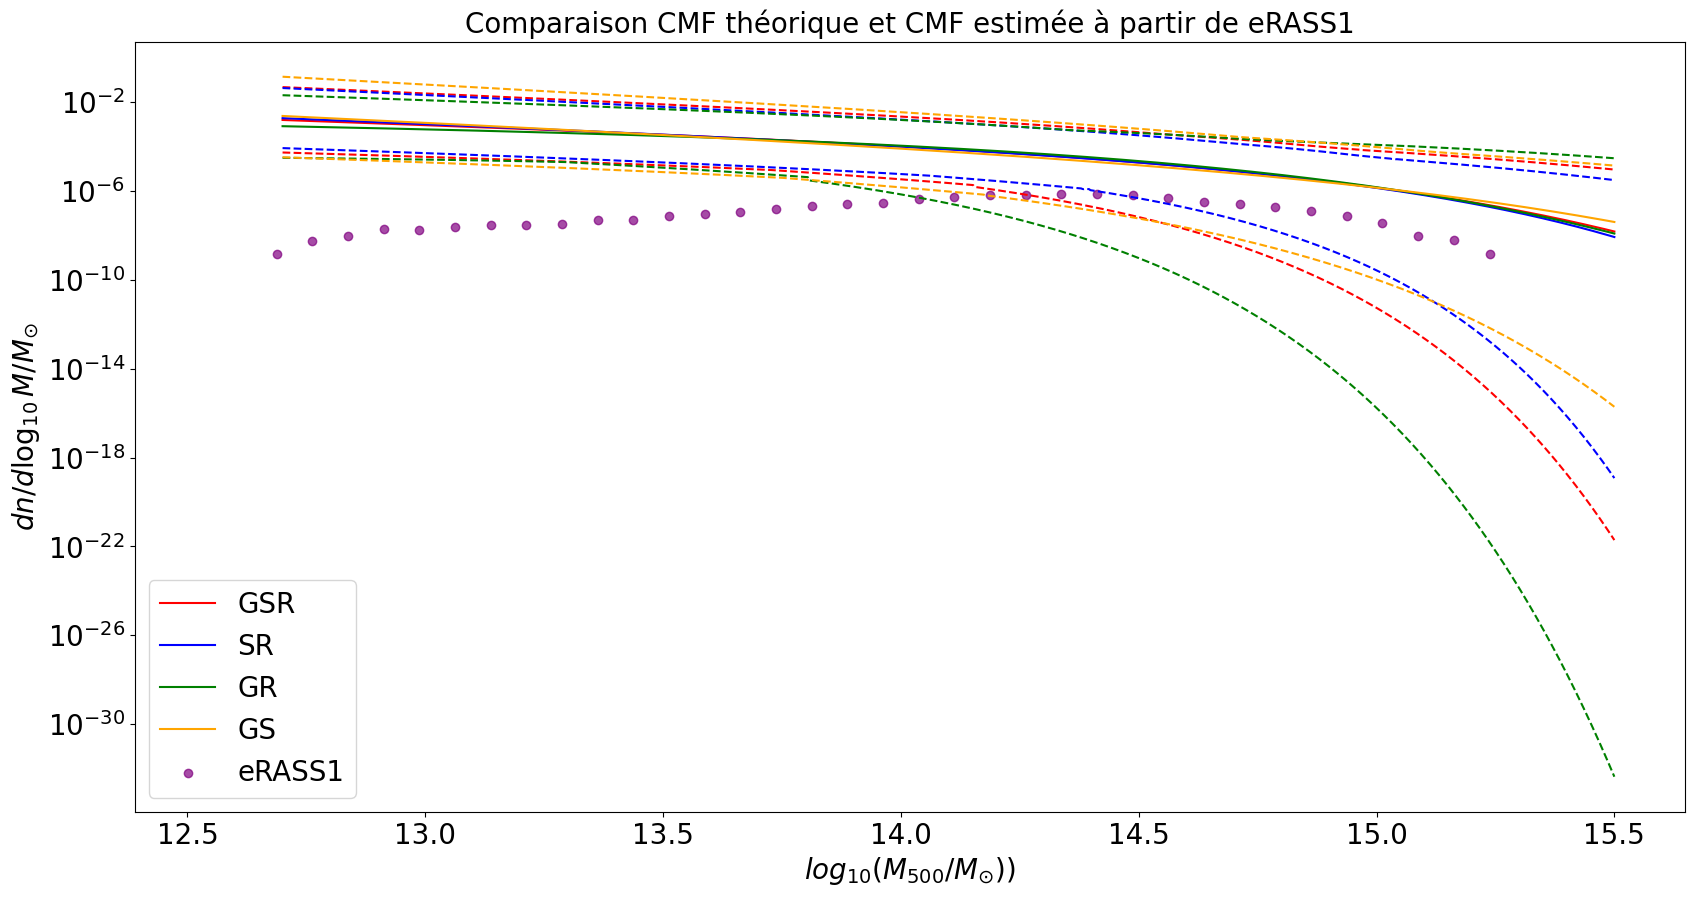

In [92]:
# Mpc ^-3 dex -1
fig = plt.figure(figsize=(20, 10))

plt.plot(log10_M_Msun, CMF_GSR, label='GSR', color='red')
plt.plot(log10_M_Msun, Borne_min_CMF_GSR, color='red',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GSR, color='red',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_SR, label='SR', color='blue')
plt.plot(log10_M_Msun, Borne_min_CMF_SR, color='blue',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_SR, color='blue',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GR, label='GR', color='green')
plt.plot(log10_M_Msun, Borne_min_CMF_GR, color='green',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GR, color='green',linestyle='dashed')

plt.plot(log10_M_Msun, CMF_GS, label='GS', color='orange')
plt.plot(log10_M_Msun, Borne_min_CMF_GS, color='orange',linestyle='dashed')
plt.plot(log10_M_Msun, Borne_max_CMF_GS, color='orange',linestyle='dashed')

plt.scatter(bin_centers, n_eRASS1, color='purple', label='eRASS1', alpha=0.7)

plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'$dn / d\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')
plt.legend()

In [93]:
'''# dex ^-1

fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR*volume_eRASS1, label='GSR', color='red')
plt.scatter(bin_centers, counts/bin_width_eRASS1, color='blue', label='eRASS1', alpha=0.7)
plt.xlabel(r'$log_{10}(M_{500}/M_{\odot})$)')
plt.ylabel(r'$\log_{10} M / M_{\odot}$')
plt.yscale('log')
plt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')
plt.legend()
'''

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\ED282972\AppData\Local\Temp\ipykernel_23040\2293506136.py:1: SyntaxWarning: invalid escape sequence '\o'
  '''# dex ^-1


"# dex ^-1\n\nfig = plt.figure(figsize=(20, 10))\nplt.plot(log10_M_Msun, CMF_GSR*volume_eRASS1, label='GSR', color='red')\nplt.scatter(bin_centers, counts/bin_width_eRASS1, color='blue', label='eRASS1', alpha=0.7)\nplt.xlabel(r'$log_{10}(M_{500}/M_{\\odot})$)')\nplt.ylabel(r'$\\log_{10} M / M_{\\odot}$')\nplt.yscale('log')\nplt.title('Comparaison CMF théorique et CMF estimée à partir de eRASS1')\nplt.legend()\n"